# Notebook 3 of 3: Mock project, part 2 - prove, screen, combine and monitor

This is the second half of the engagement started in Notebook 2. A subscription betting startup wants to sell *provable* edges found among 40 candidate signals and to combine them into one forecaster. Notebook 2 built the simulator, the signal library with its hidden truth table, the frozen forecasters and the client's naive pipeline, and it audited that pipeline against the truth: the naive registry fails acceptance criterion **AC1** (mean false-discovery proportion about 19% against a 10% target) and **AC2** (the look-ahead signal is published in about 96% of worlds). This notebook builds the replacement and scores all four criteria against that baseline: **prove** each edge with anytime-valid confidence sequences and e-processes (Choe and Ramdas), **screen** the 40 candidates with online FDR control on e-values (Xu and Ramdas, e-LOND) inside a two-stage registry that survives the look-ahead bug, **combine** the certified signals with the market by multi-calibeating (Chen, Huang, Jordan and Luo), **monitor** published edges for decay, and put a price on proof: how many live games it takes, and what the bookmaker's margin does to the money view.

**Framing.** This is a simulation study on synthetic data. It is not betting advice, and every result describes the simulator, not real markets. Statements attributed to a paper carry a section, theorem or equation number; everything else (the simulator, the two-stage registry, the monitors, the money figures, every constant) is *derived here*. Numbers from the simulator and numbers quoted from papers are printed in separate, labelled places. Several printed lines are `SELF-CHECK` lines with an explicit threshold and a `MET` / `NOT MET` verdict; a check that fails is reported, not hidden. The acceptance-criteria scorecard near the end is computed by code from the audit. It reports AC4 twice, **as written in Notebook 2 (not met)** and **with a revised detection horizon (met)**, and section 6 explains why the horizon was revised and in which order the design choices were made; a criterion that is not met is a finding about what proof costs at these effect sizes, not a defect to be tuned away.

**Roadmap.** 1 the engagement and the design constants; 2 one 200-world audit that feeds every later section; 3 prove; 4 screen; 5 combine; 6 monitor; 7 money and the picks feed; 8 the scorecard; 9 limitations and recap. Notebooks 1 and 2 are loaded through their marked `# EXPORT:` cells, so nothing from them is copied here.

In [1]:
import os
for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # single-thread BLAS (set before numpy is imported): fastest for small matrices and safe with worker processes
%matplotlib inline

import io, time, contextlib, inspect
import multiprocessing as mp
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbformat

T_START = time.time()
SEED_MC = 20260920                     # Monte Carlo seed for the restart-trap experiment (section 6)
DATA_DIR = Path("..") / "data"
DATA_DIR.mkdir(exist_ok=True)

# One palette for the whole notebook: the class colours of Notebook 2, plus the colours of the objects compared here.
PALETTE = {
    "real": "#2a9d8f", "subvig": "#e9c46a", "decay": "#f4a261", "proxy_real": "#457b9d",
    "proxy_null": "#a8b5c2", "leaky": "#e63946", "null": "#8d99ae",
    "market": "#222222", "naive": "#e63946", "single": "#f4a261", "two_stage": "#2a9d8f", "combined": "#6a4c93",
    "band": "#457b9d", "threshold": "#999999", "trap": "#e63946", "valid": "#2a9d8f",
}
CLASS_ORDER = ["real", "subvig", "decay", "proxy_real", "proxy_null", "leaky", "null"]
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

def finding(what, value, verdict):
    """A reported result of a hypothesis, not a code check: printed as FINDING and not counted among the SELF-CHECKs."""
    print(f"FINDING: {what} -> {value} -> {verdict}")

CHECKS = []
def check(what, value, threshold, ok):
    """Print one numbered SELF-CHECK line. MET is printed only if the check passed its own threshold."""
    CHECKS.append(bool(ok))
    print(f"SELF-CHECK {len(CHECKS)}: {what} -> {value} (threshold {threshold}) -> {'MET' if ok else 'NOT MET'}")
    return bool(ok)

def wilson(k, n, z=1.959964):
    """Wilson score interval for a binomial proportion k/n."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (mid - half, mid + half)

def boot_ci(x, stat=np.nanmean, B=4000, seed=0, level=0.95):
    """Percentile bootstrap over worlds for a statistic of a per-world array: (estimate, lower, upper)."""
    x = np.asarray(x, dtype=float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), (B, len(x)))
    draws = np.array([stat(x[i]) for i in idx])
    lo, hi = np.quantile(draws, [(1 - level) / 2, 1 - (1 - level) / 2])
    return float(stat(x)), float(lo), float(hi)

# ---- load the exported cells of Notebooks 1 and 2 by marker (never by cell index), NB1 first, one shared namespace ----
def load_exports(paths, namespace):
    found = []
    for p in paths:
        nb = nbformat.read(str(p), as_version=4)
        for cell in nb.cells:
            if cell.cell_type == "code" and cell.source.lstrip().startswith("# EXPORT:"):
                found.append(cell.source.lstrip().splitlines()[0].split(":", 1)[1].strip())
                with contextlib.redirect_stdout(io.StringIO()):
                    exec(cell.source, namespace)
    return found

exports = load_exports(["01_research_foundations.ipynb", "02_mock_project_part1_build.ipynb"], globals())
expected_fn = ["cr_uniform_boundary", "cr_confseq", "cr_log_eprocess", "elond", "rlond", "calibeat", "multi_calibeat",
               "simulate_world", "devig", "fit_forecasters", "brier", "score_diff", "true_gap", "is_edge", "roi_flat",
               "expected_roi_flat", "naive_screen"]
check("marked export cells of Notebooks 1 and 2 loaded by marker; all 17 functions and the CFG dictionary are defined",
      f"{len(exports)} export cells ({', '.join(exports)})", "all present",
      all(callable(globals().get(f)) for f in expected_fn) and isinstance(globals().get("CFG"), dict) and len(exports) == 15)
print("signatures:", ", ".join(f"{f}{inspect.signature(globals()[f])}" for f in ("cr_log_eprocess", "elond", "multi_calibeat", "naive_screen")))

SELF-CHECK 1: marked export cells of Notebooks 1 and 2 loaded by marker; all 17 functions and the CFG dictionary are defined -> 15 export cells (cr_boundary, cr_confseq, cr_eprocess, elond, rlond, calibeat, multi_calibeat, edgelab_config, edgelab_devig, edgelab_scores, edgelab_sim, edgelab_fit, edgelab_truth, edgelab_money, edgelab_naive) (threshold all present) -> MET
signatures: cr_log_eprocess(delta_hat, c=2.0, v_opt=10.0, alpha=0.05, last_only=False), elond(e, alpha=0.1, gamma=None), multi_calibeat(Q, y, nbins=10, eta=None), naive_screen(W, F, alpha=0.05, fit_on='eval', mask=None)


## 1. The engagement, part 2: what is delivered, on which timeline, with which constants

**Deliverables** (from the Notebook 2 brief) and the tool that answers each:

| # | Deliverable | Built here with |
|---|---|---|
| D1 | Registry of candidate edges: a verdict per signal that can be defended to a member | e-processes and confidence sequences per signal (**prove**), e-LOND over the 40 signals (**screen**), two-stage so that a look-ahead bug cannot pass |
| D2 | One combined forecaster, not worse than the market | multi-calibeating over the market and the certified signals (**combine**) |
| D3 | Honest money view | flat-stake ROI at the margined odds, in Brier terms and in money terms (**money**) |
| D4 | Edge-decay monitor | pre-specified block e-processes and the full-history confidence sequence (**monitor**) |

**Acceptance criteria** (fixed in Notebook 2; the numeric tolerances there are derived, not taken from a paper): **AC1** mean false-discovery proportion (FDP) among published signals $\le 10\%$; **AC2** a signal that violates predictability is published in at most 1% of worlds; **AC3** the lower end of a valid 95% interval for the combined forecast's mean Brier differential against the de-margined market is at least $-0.0005$; **AC4** a decaying edge is flagged within 3,690 games (three seasons) of its decay onset, with at most 5% false alarms per world on edges that do not decay. **This notebook scores AC4 twice**: exactly as written, and with a *revised horizon of 14,760 games (12 seasons, the length of the certification window)*, because the written horizon lies at the ceiling of what even an oracle test can reach (section 6 gives the arithmetic and the order in which the choices were made).

**Timeline** (each simulated world has 30 seasons of 1,230 games):

| Seasons | Role | Note |
|---|---|---|
| 1-3 | training | slopes of the 40 single-signal forecasters are fitted here and then frozen (Notebook 2) |
| 4-12 | **backtest window** (11,070 games) | the historical feature build **includes the look-ahead leak** of the leaky signal |
| 13-24 | **certification window** (up to 14,760 games) | live, causal: the leak is absent; used only by stage 2 of the registry and by the cost-of-proof curve |
| 25-30 | **fresh evaluation window** (7,380 games) | live, causal, never seen by the registry: where the combined forecaster and its AC3 interval are judged |

The monitors of section 6 replay seasons 4-30 as if games arrived after a launch at the start of season 4; the decaying signal loses its edge after season 4 (Notebook 2), so its decay onset is the start of season 5.

**Why the live window is long (derived here).** The effect sizes planted in Notebook 2 are 2 to 3.5 percentage points of win probability per standard deviation of a signal, i.e. mean Brier gains of about $3\times10^{-4}$ to $10\times10^{-4}$ per game against a per-game standard deviation of the score differential of about 0.03. A signal with a mean gain of $6\times10^{-4}$ has a $z$-statistic of only $0.02\sqrt{n}$ after $n$ games, so about 22,000 games are needed for $z=3$, and an e-value that must clear a multiplicity-adjusted threshold needs still more. The papers' own real-data example lives on the same scale: for FiveThirtyEight against Vegas on 25,165 MLB games the 95% empirical-Bernstein confidence sequence ends at $(-0.00265,-0.00061)$ and first excludes zero at about $t=10{,}000$ (Choe and Ramdas, Sec. 5.2, paper numbers). Twelve live seasons for certification and six for evaluation are horizons long enough for the pipeline to have something to say, and the cost of proof is one of the results.

**Design constants** (all *derived here*; chosen on 30 prototype worlds with seeds 900-929, which are disjoint from the 200 audit seeds; none was tuned on the audit worlds):

| Constant | Value | Role |
|---|---|---|
| `KAPPA` | 0.08 | every registered forecaster is the frozen forecast **capped to within $\pm0.08$ of the market** (fixed rule; it binds in well under 1% of games) |
| `C_SCALE` $=4\kappa$ | 0.32 | with the cap, $|S(p,y)-S(q,y)|\le|p-q|\max(p+q,\,2-p-q)<2\kappa$, so the boundedness condition of Thm 2, $|\hat\delta_i|\le c/2$, holds *ex ante* with $c=0.32$ instead of the worst-case $c=2$ |
| `V_OPT` | 10 | intrinsic time at which the boundary is tightest; used for the confidence sequence **and** for the e-process so that the duality of Cor. 1 holds exactly. Chosen on the prototype worlds from the grid 1, 3, 10, 25, 60: registry power peaks near 10 and is nearly flat from 3 to 25 |
| `ALPHA_MON` | 0.10 | level of the monitor's confidence sequence: a two-sided 90% sequence is a *one-sided 5%* test for the alarm 'the market is better', i.e. the whole AC4 false-alarm budget (the 95% sequence spent only 2.5% of it) |
| `ALPHA_CS` / `ALPHA_FDR` | 0.05 / 0.10 | confidence level of every sequence; e-LOND level, equal to the AC1 target so that the theorem itself implies AC1 |
| `NBINS` | 20 | calibeating grid, so $|Q|\le20$ distinct forecast values |
| `SHORTLIST_LOGE` | 1.0 | stage 1 shortlists a signal whose backtest e-value is at least $e$ |

The cap matters because the scale $c$ enters the sub-exponential term of the mixture: the worst-case $c=2$ would give a much wider boundary than $c=0.32$ for the same data. An earlier version of this notebook used $v_{\rm opt}=0.3$; that value had been chosen while the tuning map of the boundary in Notebook 1 was inverted (an error found by reproducing the paper's MLB numbers in Notebook 4), and it was re-chosen on the prototype worlds after the fix.

In [2]:
# ---- design constants of this notebook (derived here; chosen on prototype worlds 900-929, disjoint from the audit seeds) ----
KAPPA = 0.08                  # cap on |p - q| for every registered forecaster: makes |delta_hat| <= 2*KAPPA hold ex ante
C_SCALE = 4 * KAPPA           # Thm 2 scale c: |delta_hat_i| <= c/2 = 2*KAPPA  ->  c = 0.32
V_OPT = 10.0                  # intrinsic time at which the gamma-exponential boundary is tightest (same value for CS and e-process); re-tuned on prototype worlds 900-929 after the tuning-map fix (grid 1, 3, 10, 25, 60)
ALPHA_CS = 0.05               # confidence sequences: 95%
ALPHA_FDR = 0.10              # e-LOND level (= the AC1 target)
N_WORLDS = 200
WORLD_SEEDS = 1000 + np.arange(N_WORLDS)      # the same seeds as the Notebook 2 audit (the worlds differ: 18 live seasons instead of 3)
FWD = 18                      # live seasons simulated per world: seasons 13..30
CERT_L = 12                   # live seasons used by the registry (stage 2): seasons 13..24
L_GRID = (3, 6, 9, 12)        # pre-specified certification horizons (seasons) for the cost-of-proof curve
EVAL_FIRST, EVAL_LAST = 25, 30   # fresh live seasons for judging the combined forecaster (never used by the registry)
NBINS = 20                    # calibeating grid: |Q| = 20 distinct forecast values
SHORTLIST_LOGE = 1.0          # stage 1: shortlist a signal when its backtest e-value is at least e
ALPHA_MON = 0.10              # monitor: two-sided 90% CS = one-sided 5% for the 'market is better' alarm, i.e. the whole AC4 false-alarm budget (was 0.05, spending only 2.5%)
AC4_ORIG, AC4_REV = 3690, 14760   # AC4 horizon as written in Notebook 2 (3 seasons) and the revised horizon (12 seasons, the certification window); see section 6
CFG3 = {**CFG, "forward_seasons": FWD}
NAMES, FAMILY, _cls, SID = _signal_layout()      # fixed layout of the 40 signals (from the exported simulator cell)
CLS = np.array(_cls, dtype=object)
STABLE_EDGE = np.isin(CLS, ["real", "subvig", "proxy_real"])     # the 8 genuine edges that do NOT decay
IS_DECAY, IS_LEAKY = CLS == "decay", CLS == "leaky"

from scipy.special import logsumexp

def cap_forecasts(P, q, kappa=KAPPA):
    """Registered forecaster = frozen forecast, capped to within +-kappa of the market (a fixed, pre-specified rule).
    Then |S(p,y) - S(q,y)| <= |p-q| * max(p+q, 2-p-q) < 2*kappa for every game, so Thm 2 holds ex ante with c = 4*kappa."""
    P = np.asarray(P, dtype=float)
    qq = q[:, None] if P.ndim == 2 else q
    return qq + np.clip(P - qq, -kappa, kappa)

def log_e_last(delta_TS, c=None, v_opt=None):
    """log E_T of the mixture e-process for the weak null 'signal no better than the market' (exported cr_log_eprocess);
    delta_TS has shape (T, S): games first, signals last."""
    return cr_log_eprocess(np.asarray(delta_TS, dtype=float).T, c=C_SCALE if c is None else c, v_opt=V_OPT if v_opt is None else v_opt,
                           alpha=ALPHA_CS, last_only=True)

def running_weak_null_flag(exact_TS, burn=1230):
    """Weak-null truth (Eq. 18) from the EXACT per-game gaps: the max over t >= burn of the running mean Delta_t. Positive means the
    weak null 'Delta_t <= 0 for all t' is FALSE (after a burn-in of `burn` games). burn=1 is the letter of Eq. 18."""
    cm = np.cumsum(exact_TS, axis=0) / np.arange(1, len(exact_TS) + 1)[:, None]
    return cm[burn - 1:].max(axis=0)

def registry_single(logE_bt, alpha=ALPHA_FDR, flat=True):
    """Single-stage registry: e-LOND on the backtest e-values of all 40 signals, in registration (signal id) order."""
    E = np.exp(np.minimum(logE_bt, 700.0))
    g = np.full(len(E), 1.0 / len(E)) if flat else None
    return elond(E[None, :], alpha, g)[0][0]

def shortlist_stage1(logE_bt, thr=SHORTLIST_LOGE):
    return logE_bt >= thr

def registry_stage2(logE_live, shortlist, alpha=ALPHA_FDR, flat=True):
    """Stage 2: e-LOND, in signal-id order, on the LIVE e-values of the shortlisted signals only. flat gamma = 1/K' over the shortlist."""
    pub = np.zeros(len(logE_live), dtype=bool)
    idx = np.where(shortlist)[0]
    if len(idx) == 0:
        return pub
    E = np.exp(np.minimum(logE_live[idx], 700.0))
    g = np.full(len(idx), 1.0 / len(idx)) if flat else None
    pub[idx] = elond(E[None, :], alpha, g)[0][0]
    return pub

def hedge_mix(Pm, y, eta=0.5):
    """Hedge (exponential weights, eta = 1/2 as in the exported multi_calibeat) over the columns of Pm (T, N); weights at t use losses before t."""
    loss = (Pm - y[:, None]) ** 2
    cb = np.cumsum(loss, axis=0) - loss
    z = -eta * cb
    z -= z.max(axis=1, keepdims=True)
    w = np.exp(z)
    w /= w.sum(axis=1, keepdims=True)
    return (w * Pm).sum(axis=1), w

def first_true(mask2d):
    """First True index along the last axis, -1 if none."""
    any_ = mask2d.any(axis=-1)
    return np.where(any_, np.argmax(mask2d, axis=-1), -1)

def scan_starts_logE(Sfull, Qfull, t, starts, c=None, v_opt=None):
    """log E of the 'market is better' e-process for every candidate block start in `starts`, block end t (games since launch), with the
    trivial predictable centring gamma_i = 0 (so V = sum of delta_hat^2; a valid choice in Thm 2). Sfull, Qfull: (S, T+1) cumulative sums of
    delta_hat and delta_hat^2 (signal minus market) with a leading zero. Returns an array (S, len(starts))."""
    rho = _cr_rho(ALPHA_CS / 2.0, V_OPT if v_opt is None else v_opt)
    s_b = -(Sfull[:, [t]] - Sfull[:, starts])
    v_b = Qfull[:, [t]] - Qfull[:, starts]
    return _cr_log_m(s_b, v_b, rho, C_SCALE if c is None else c)

print(f"design: cap kappa={KAPPA}, scale c={C_SCALE}, v_opt={V_OPT}, CS level {1 - ALPHA_CS:.0%}, e-LOND level {ALPHA_FDR}, "
      f"{N_WORLDS} worlds x (12 historical + {FWD} live) seasons, grid |Q|={NBINS}")

design: cap kappa=0.08, scale c=0.32, v_opt=10.0, CS level 95%, e-LOND level 0.1, 200 worlds x (12 historical + 18 live) seasons, grid |Q|=20


## 2. One audit for the whole notebook: 200 worlds, 12 historical and 18 live seasons each

Every later section reads from the same audit. In each of 200 independent worlds (the seeds of the Notebook 2 audit; each world redraws schedule, team strengths, referees, features, effect signs, market noise and outcomes) the function below simulates 12 historical and 18 live seasons, fits the frozen forecasters, caps them, and records **everything the sections need**: the exact truth (per-signal exact gap on each window, from the simulator's true win probability), the log e-values on the backtest window and on each certification horizon, the client's naive screen on the same world, confidence sequences on the live window (coverage and games to certify), the four monitors, the combined forecasters on the fresh evaluation window, and the exact expected ROI of every signal. Storing only small per-world arrays keeps the notebook light; nothing is drawn twice.

Two conventions used throughout:

* **The e-value of a signal** is the gamma-exponential mixture e-process for the weak null $H_0^w$: "the signal is no better than the market on average, at every $t$" (Choe and Ramdas Thm 3 and Prop. 3), stopped at the fixed end of a window. A stopped e-process is a valid e-value (Eq. 23; Xu and Ramdas Sec. 2, Eq. 4), which is what e-LOND consumes.
* **Predictability.** The registered forecast of game $g$ is a function of the game's own pre-game features, the market price and slopes fitted in seasons 1-3, capped around the market: it is predictable in the sense of Choe and Ramdas Sec. 4.2. The single exception is the leaky signal in the **backtest** window, whose feature contains the outcome. The live seasons of every world are causal (Notebook 2).

The audit runs in parallel worker processes when the platform allows it and is cached in `data/` (regenerated if absent or if the constants changed).

In [3]:
HALF = 615                                   # candidate block starts of the data-chosen-start scan: every half season
def season_slices(s):
    return {j: np.where(s == j)[0] for j in np.unique(s)}

def run_world(seed):
    """Everything the notebook needs from ONE simulated world (12 historical + 18 live seasons). Returns a dict of small arrays."""
    W = simulate_world(int(seed), CFG3)
    F = fit_forecasters(W, CFG3)
    q, y, r, s = W["m_devig"], W["y"].astype(float), W["r_true"], W["season"]
    oh, oa = W["odds_home"], W["odds_away"]
    P = cap_forecasts(F["P"], q)                         # registered (capped) forecasters, (G, 40)
    d = score_diff(P, q[:, None], y[:, None])            # realised differential, positive = signal better
    ex = (q - r)[:, None] ** 2 - (P - r[:, None]) ** 2   # exact per-game expected differential given pre-game information
    bt = (s >= 4) & (s <= 12)
    live = lambda L: (s >= 13) & (s <= 12 + L)
    evalw = (s >= EVAL_FIRST) & (s <= EVAL_LAST)
    rec = dict(seed=np.array(seed), max_abs_delta=np.array(np.abs(d).max()), max_abs_dev=np.array(np.abs(P - q[:, None]).max()))
    # --- truth and e-values for the backtest window and each certification horizon ---
    rec["gap_bt"] = ex[bt].mean(0)
    rec["wk1_bt"] = running_weak_null_flag(ex[bt], 1)
    rec["wk_bt"] = running_weak_null_flag(ex[bt], 1230)
    rec["logE_bt"] = log_e_last(d[bt])
    rec["gap_L"] = np.array([ex[live(L)].mean(0) for L in L_GRID])
    rec["wk1_L"] = np.array([running_weak_null_flag(ex[live(L)], 1) for L in L_GRID])
    rec["wk_L"] = np.array([running_weak_null_flag(ex[live(L)], 1230) for L in L_GRID])
    rec["logE_L"] = np.array([log_e_last(d[live(L)]) for L in L_GRID])
    # --- the client's naive pipeline on the same world (backtest window only) ---
    na = naive_screen(W, F, alpha=0.05)
    rec["naive_p"], rec["naive_sel"] = na["pvals"], na["selected"]
    # --- confidence sequences on the live seasons: coverage of the exact running mean, and games to certify (games from live start) ---
    dl, exl = d[live(FWD)], ex[live(FWD)]
    lo, up = cr_confseq(dl.T, ALPHA_CS, c=C_SCALE, v_opt=V_OPT)
    Dexact = (np.cumsum(exl, 0) / np.arange(1, len(exl) + 1)[:, None]).T
    rec["cover_live"] = ((Dexact >= lo) & (Dexact <= up)).all(axis=1)
    rec["first_cert"] = first_true(lo > 0)                       # 0-based game index of the first t with lower > 0, -1 = never
    dbt = d[bt]
    lob, upb = cr_confseq(dbt.T, ALPHA_CS, c=C_SCALE, v_opt=V_OPT)
    rec["cs_bt_lower_last"] = lob[:, -1]
    rec["cs_bt_excludes0"] = lob[:, -1] > 0
    # --- monitors (launch = start of season 4; delta series signal-minus-market over seasons 4..30) ---
    m4 = s >= 4
    x = d[m4]; sx = s[m4]
    lof, upf = cr_confseq(x.T, ALPHA_MON, c=C_SCALE, v_opt=V_OPT)      # full-history CS since launch (anytime valid, every game), one-sided level 5% = the AC4 false-alarm budget
    rec["first_full"] = first_true(upf < 0)                              # game index since launch of the first 'market better' alarm
    tt = np.arange(1, len(x) + 1)[:, None]                                 # the client's dashboard: a fixed-time 95% z-interval refreshed after every game
    mu_t = np.cumsum(x, 0) / tt
    sd_t = np.sqrt(np.maximum(np.cumsum(x ** 2, 0) / tt - mu_t ** 2, 1e-12))
    dash = ((mu_t + 1.959964 * sd_t / np.sqrt(tt)) < 0) & (tt >= 30)
    rec["first_dash"] = first_true(dash.T)
    sl = season_slices(sx)
    ends = {j: sl[j][-1] for j in sl}
    firsts = {j: sl[j][0] for j in sl}
    S = np.concatenate([np.zeros((40, 1)), np.cumsum(x, 0).T], 1)
    Q2 = np.concatenate([np.zeros((40, 1)), np.cumsum(x ** 2, 0).T], 1)
    blk_alarm = np.zeros((31, 40), dtype=bool); trap_alarm = np.zeros((31, 40), dtype=bool)
    nmax = int(sx.max())
    for j in range(5, nmax + 1):
        k = j - 4
        thr_blk = np.log(1.0 / (ALPHA_CS * (1.0 / (k * (k + 1)))))            # discount gamma_k = 1/(k(k+1)) over season-end checkpoints
        a, b = firsts[max(4, j - 2)], ends[j]
        le = log_e_last(-x[a:b + 1])                                          # trailing 3 seasons, market-is-better direction (App. F.1, xi fixed in advance)
        blk_alarm[j] = le >= thr_blk
        t_end = ends[j] + 1
        starts = np.arange(0, t_end - 100, HALF)
        trap_alarm[j] = (scan_starts_logE(S, Q2, t_end, starts).max(axis=1) >= np.log(2.0 / ALPHA_CS))   # data-chosen block start, nominal level
    rec["blk_alarm"], rec["trap_alarm"] = blk_alarm, trap_alarm
    # --- combined forecaster, judged on fresh live seasons 25..30 ---
    logE_L12 = rec["logE_L"][L_GRID.index(CERT_L)]
    pub_two = registry_stage2(logE_L12, shortlist_stage1(rec["logE_bt"]))
    rec["pub_two"] = pub_two
    rec["pub_single_flat"] = registry_single(rec["logE_bt"], flat=True)
    rec["pub_single_default"] = registry_single(rec["logE_bt"], flat=False)
    pub_ids = np.where(pub_two)[0]
    mh = s >= 4
    yh, qh, rh = y[mh], q[mh], r[mh]
    ev_h = evalw[mh]
    calq = calibeat(qh, yh, nbins=NBINS)
    cols = [qh, calq]
    for j in pub_ids:
        cols += [P[mh, j], calibeat(P[mh, j], yh, nbins=NBINS)]
    hyb, wts = hedge_mix(np.stack(cols, 1), yh)
    mc, _ = multi_calibeat(np.stack([qh] + [P[mh, j] for j in pub_ids], 0), yh, nbins=NBINS)
    stack = na["stack_P"][mh]
    outs = dict(calq=calq, multical=mc, hybrid=hyb, naive_stack=stack)
    if len(pub_ids) > 0:
        outs["published_only"] = np.mean([P[mh, j] for j in pub_ids], axis=0)      # equal-weight average of the published signals' forecasts
    else:
        outs["published_only"] = qh.copy()
    snap = (np.minimum(np.floor(np.clip(qh, 0, 1) * NBINS).astype(int), NBINS - 1) + 0.5) / NBINS
    for name, f in outs.items():
        fc = qh + np.clip(f - qh, -KAPPA, KAPPA)                                   # same cap: Thm 2 boundedness holds ex ante
        dd = (brier(fc, yh) - brier(qh, yh))[ev_h]
        lo1, up1 = cr_confseq(dd[None, :], ALPHA_CS, c=C_SCALE, v_opt=V_OPT)
        rec[f"comb_{name}_lower"], rec[f"comb_{name}_upper"] = lo1[0, -1], up1[0, -1]
        rec[f"comb_{name}_gap"] = ((qh - rh) ** 2 - (fc - rh) ** 2)[ev_h].mean()
        e_edge = expected_roi_flat(fc, oh[mh], oa[mh], rh, mask=ev_h, rule="edge")
        rec[f"comb_{name}_roi_edge"], rec[f"comb_{name}_nbets"] = e_edge["roi"], e_edge["n_bets"]
        rec[f"comb_{name}_maxdev"] = np.abs(f - qh)[ev_h].max()
    rec["comb_calq_gap_vs_snap"] = ((snap - rh) ** 2 - (outs["calq"] - rh) ** 2)[ev_h].mean()
    rec["comb_snap_gap_vs_market"] = ((qh - rh) ** 2 - (snap - rh) ** 2)[ev_h].mean()
    r0 = np.clip(1.0 / (1.0 + np.exp(-CFG["a_longshot"] * np.log(W["m_fair"] / (1 - W["m_fair"])))), 0.051, 0.949)
    rec["oracle_price_gain"] = ((q - r) ** 2 - (r0 - r) ** 2)[evalw].mean()
    rec["hyb_weight_market_final"] = wts[-1, 0]
    rec["n_pub_two"] = np.array(len(pub_ids))
    # --- money: exact expected ROI of every capped forecaster on the fresh live window, both rules ---
    for rule in ("edge", "follow"):
        e = expected_roi_flat(P, oh, oa, r, mask=evalw, rule=rule, q=q)
        rec[f"roi_{rule}"], rec[f"nb_{rule}"] = e["roi"], e["n_bets"]
    rec["gap_eval"] = ex[evalw].mean(0)
    return rec

In [4]:
t0 = time.time()
CACHE = DATA_DIR / "nb03_audit_200worlds.npz"
SIGNATURE = (repr(sorted(CFG3.items())) + f"|{KAPPA}|{V_OPT}|{ALPHA_CS}|{ALPHA_FDR}|{N_WORLDS}|{WORLD_SEEDS[0]}|{FWD}|{CERT_L}|{L_GRID}|"
             f"{EVAL_FIRST}-{EVAL_LAST}|{NBINS}|{SHORTLIST_LOGE}|{ALPHA_MON}|v3")

def run_audit():
    seeds = [int(x) for x in WORLD_SEEDS]
    workers = int(os.environ.get("NB3_WORKERS", max(1, min(8, (os.cpu_count() or 2) - 1))))
    cr_uniform_boundary(np.array([1.0]), alpha_side=ALPHA_CS / 2, c=C_SCALE, v_opt=V_OPT)   # build the boundary grid once, before forking, so workers inherit it
    if "fork" in mp.get_all_start_methods() and workers > 1:
        with mp.get_context("fork").Pool(workers) as pool:
            recs = pool.map(run_world, seeds, chunksize=2)
        return {k: np.array([r[k] for r in recs]) for k in recs[0]}, workers
    recs = [run_world(s) for s in seeds]
    return {k: np.array([r[k] for r in recs]) for k in recs[0]}, 1

A, from_cache, workers = None, False, 0
if CACHE.exists():
    z = np.load(CACHE, allow_pickle=False)
    if str(z["signature"]) == SIGNATURE:
        A = {k: z[k] for k in z.files if k != "signature"}
        from_cache = True
if A is None:
    A, workers = run_audit()
    np.savez(CACHE, signature=np.array(SIGNATURE), **A)
AUDIT_SECONDS = time.time() - t0
print(f"audit: {len(A['seed'])} worlds x 30 seasons, {'loaded from cache' if from_cache else f'simulated with {workers} worker process(es)'} ({AUDIT_SECONDS:.0f}s)")

chk = run_world(int(WORLD_SEEDS[7]))
check("cache integrity: re-running world #8 from scratch reproduces its stored e-values, registry outputs and combined-forecaster gap",
      f"max |dlogE| {np.abs(chk['logE_bt'] - A['logE_bt'][7]).max():.1e}, {np.abs(chk['comb_hybrid_gap'] - A['comb_hybrid_gap'][7]):.1e}", "== 0 (to 1e-9)",
      np.allclose(chk["logE_bt"], A["logE_bt"][7], atol=1e-9) and np.allclose(chk["logE_L"], A["logE_L"][7], atol=1e-9)
      and np.array_equal(chk["pub_two"], A["pub_two"][7]) and abs(chk["comb_hybrid_gap"] - A["comb_hybrid_gap"][7]) < 1e-9)
check("audit size and shapes: worlds, seed list, and per-world arrays of 40 signals x 4 certification horizons",
      f"{A['logE_bt'].shape}, {A['logE_L'].shape}, seeds {int(A['seed'][0])}..{int(A['seed'][-1])}", "(200, 40), (200, 4, 40), 1000..1199",
      A["logE_bt"].shape == (200, 40) and A["logE_L"].shape == (200, 4, 40) and int(A["seed"][0]) == 1000 and int(A["seed"][-1]) == 1199)
check("the cap makes Thm 2's boundedness hold ex ante: max |delta_hat| over all games, signals and worlds, and max |p - q|",
      f"{A['max_abs_delta'].max():.4f} and {A['max_abs_dev'].max():.4f}", "|delta_hat| <= c/2 = 0.16 and |p-q| <= 0.08",
      A["max_abs_delta"].max() <= C_SCALE / 2 and A["max_abs_dev"].max() <= KAPPA + 1e-12)

audit: 200 worlds x 30 seasons, simulated with 12 worker process(es) (16s)


SELF-CHECK 2: cache integrity: re-running world #8 from scratch reproduces its stored e-values, registry outputs and combined-forecaster gap -> max |dlogE| 0.0e+00, 0.0e+00 (threshold == 0 (to 1e-9)) -> MET
SELF-CHECK 3: audit size and shapes: worlds, seed list, and per-world arrays of 40 signals x 4 certification horizons -> (200, 40), (200, 4, 40), seeds 1000..1199 (threshold (200, 40), (200, 4, 40), 1000..1199) -> MET
SELF-CHECK 4: the cap makes Thm 2's boundedness hold ex ante: max |delta_hat| over all games, signals and worlds, and max |p - q| -> 0.1369 and 0.0800 (threshold |delta_hat| <= c/2 = 0.16 and |p-q| <= 0.08) -> MET


True

## 3. Prove: anytime-valid evidence that a signal beats the market

**What the paper gives (Choe and Ramdas, *Comparing Sequential Forecasters*).** Two forecasters $p_t,q_t$ issue forecasts before the outcome $y_t$ is revealed; reality picks $r_t=\mathbb E_{t-1}[y_t]$ with no stationarity assumption (Game 1, Sec. 4.1; Eq. 7). The target is the *moving* average score gap $\Delta_t=\frac1t\sum_{i\le t}\mathbb E_{i-1}[S(p_i,y_i)-S(q_i,y_i)]$ (Eq. 8), estimated by $\hat\Delta_t$ (Eq. 9); the forecasts must be **predictable** with respect to the game filtration (Sec. 4.2). Under a bound $|\hat\delta_i|\le c/2$ the empirical-Bernstein confidence sequence $\hat\Delta_t\pm u(\hat V_t)/t$ with $\hat V_t=\sum_i(\hat\delta_i-\gamma_i)^2$ and predictable centring $\gamma_i=\hat\Delta_{i-1}$ is a $(1-\alpha)$ confidence sequence for $\Delta_t$ (**Thm 2, Eq. 15**), i.e. $P(\exists t:\Delta_t\notin C_t)\le\alpha$ (Eq. 2), valid at every stopping time (Eq. 3). The boundary $u$ is the gamma-exponential mixture (Sec. 4.3.4, App. B.1, Eq. 41 and Eq. 43), tuned by $v_{\rm opt}$ through $\rho=v_{\rm opt}/\big(2\log(1/\alpha)+\log(1+2\log(1/\alpha))\big)$ (App. B.1, read as the authors' code reads it). For the weak null $H_0^w(p,q):\Delta_t\le0$ for all $t$ (Eq. 18) the mixture $E_t^{\rm mix}$ is an **e-process** (**Thm 3**; Eq. 23: $\mathbb E_P[E_\tau]\le1$ at every stopping time). The two are dual: rejecting when the lower end exceeds 0 (Cor. 1, Eq. 19) is the same event as $E_t\ge2/\alpha$, which the paper illustrates in its experiments (Sec. 4.4 and 5.1).

**What we do with it (derived here).** Each of the 40 registered forecasters is compared with the de-margined market. The claim we want to certify for a signal is "its mean Brier gap over the market is positive". Four things must hold for that claim to mean anything, and each is checked below:

1. the confidence sequence covers the exact running gap $\Delta_t$ (known to the simulator) at every $t$ on the live window, in at least 95% of signal-worlds;
2. the e-value of a signal with no edge has mean at most 1 (the defining property of an e-value, Xu and Ramdas Eq. 3);
3. the CS and the e-process agree exactly (duality) when they share $c$, $v_{\rm opt}$ and $\alpha$;
4. **the guarantees are void when predictability fails.** The leaky signal's backtest forecasts use the outcome, so on the backtest window its confidence sequence will "prove" superiority that does not exist, while on the live window (where the leak is absent) it behaves.

The last point is why the registry of section 4 cannot rely on the backtest alone. Everything here is *descriptive, not predictive*: a sequence summarises the gap realised so far and says nothing about the future (Choe and Ramdas, Sec. 5.2 and 6).

In [5]:
t0 = time.time()
# Showcase world: the first audit world (by seed) in which the two-stage registry of section 4 publishes at least one signal (rule fixed in advance).
SHOW_I = int(np.argmax(A["pub_two"].sum(1) >= 1)); SHOW_SEED = int(A["seed"][SHOW_I])
WS = simulate_world(SHOW_SEED, CFG3); FS = fit_forecasters(WS, CFG3)
qS, yS, rS, sS, ohS, oaS = WS["m_devig"], WS["y"].astype(float), WS["r_true"], WS["season"], WS["odds_home"], WS["odds_away"]
PS = cap_forecasts(FS["P"], qS)
dS = score_diff(PS, qS[:, None], yS[:, None])
exS = (qS - rS)[:, None] ** 2 - (PS - rS[:, None]) ** 2
cap_bind = float((np.abs(FS["P"] - qS[:, None]) > KAPPA).mean())
check("the +-0.08 cap binds in a small share of (game, signal) forecasts (showcase world)", f"{100 * cap_bind:.3f}%", "< 1%", cap_bind < 0.01)

REAL, LEAK, NULL, DEC = SID["form_02"], SID["form_16"], SID["ref_01"], SID["form_05"]
btS, liveS = (sS >= 4) & (sS <= 12), sS >= 13
def cs_path(sig, mask):
    d = dS[mask, sig]
    lo, up = cr_confseq(d[None, :], ALPHA_CS, c=C_SCALE, v_opt=V_OPT)
    le = cr_log_eprocess(d[None, :], c=C_SCALE, v_opt=V_OPT, alpha=ALPHA_CS)
    Dh = np.cumsum(d) / np.arange(1, len(d) + 1)
    Dx = np.cumsum(exS[mask, sig]) / np.arange(1, len(d) + 1)
    return dict(lo=lo[0], up=up[0], le=le[0], Dhat=Dh, Dexact=Dx)
paths = {"real_live": cs_path(REAL, liveS), "leak_bt": cs_path(LEAK, btS), "leak_live": cs_path(LEAK, liveS),
         "null_live": cs_path(NULL, liveS), "real_bt": cs_path(REAL, btS)}

# (3) duality of Cor. 1: {CS lower > 0} == {E_t >= 2/alpha} at every t, same c, v_opt, alpha
thr2 = np.log(2.0 / ALPHA_CS)
dual = all(np.array_equal(p["lo"] > 0, p["le"] >= thr2 - 1e-9) for p in paths.values())
first_cs = {k: int(np.argmax(p["lo"] > 0)) + 1 if (p["lo"] > 0).any() else None for k, p in paths.items()}
first_e = {k: int(np.argmax(p["le"] >= thr2 - 1e-9)) + 1 if (p["le"] >= thr2 - 1e-9).any() else None for k, p in paths.items()}
check("duality (Cor. 1): the games at which the CS lower end is > 0 and the games at which E_t >= 2/alpha coincide, five showcase paths",
      f"first t (CS) {first_cs}; first t (e-process) {first_e}", "identical event at every t", dual)

# (1) coverage of the exact running gap, live window, all 40 signals in all worlds
cover = A["cover_live"]
miscov = 1 - cover.mean()
worlds_all = cover.all(axis=1).mean()
check("the 95% confidence sequence covers the exact running gap Delta_t at EVERY t of the 18 live seasons: whole-horizon miscoverage over 200 worlds x 40 signals",
      f"{100 * miscov:.2f}% of signal-worlds ({100 * (1 - worlds_all):.1f}% of worlds have at least one miss)", "<= 5%", miscov <= ALPHA_CS)
# (2) e-values of no-edge signals have mean <= 1, on the backtest and on the live certification window
null_like = np.isin(CLS, ["null", "proxy_null"])
def mean_e(logE):
    e = np.exp(np.minimum(logE[:, null_like], 50)).ravel()
    return e.mean(), e.std(ddof=1) / np.sqrt(len(e))
for lab, X in (("backtest window", A["logE_bt"]), ("12 live seasons", A["logE_L"][:, L_GRID.index(12), :])):
    m_e, se_e = mean_e(X)
    check(f"e-value validity: mean e-value of the {null_like.sum()} no-effect signals over 200 worlds, {lab} (E[E] <= 1 under the null, Xu-Ramdas Eq. 3)",
          f"{m_e:.3f} (max {np.exp(np.minimum(X[:, null_like], 50)).max():.2f})", f"<= 1 + 3 s.e. = {1 + 3 * se_e:.3f}", m_e <= 1 + 3 * se_e)
# (4) the leak: the backtest 'proves' something false, the live window does not
lk_bt = A["cs_bt_excludes0"][:, IS_LEAKY].mean()
real_bt = A["cs_bt_excludes0"][:, CLS == "real"].mean()
lk_live = (A["first_cert"][:, IS_LEAKY] >= 0).mean()
lk_true_gap = A["gap_bt"][:, IS_LEAKY].max()
check("look-ahead bug: the 95% CS on the backtest window excludes zero from below for the leaky signal (share of worlds), while its exact gap is negative in every world",
      f"{lk_bt:.3f} of worlds (exact gap max {1e4 * lk_true_gap:.2f}e-4; genuine real edges: {real_bt:.3f}; mean backtest e-value of the leaky signal {np.exp(np.minimum(A['logE_bt'][:, IS_LEAKY], 50)).mean():.3g})",
      "share > 0.5 and exact gap < 0", lk_bt > 0.5 and lk_true_gap < 0)
lo_l, hi_l = wilson(int((A["first_cert"][:, IS_LEAKY] >= 0).sum()), N_WORLDS)
check("on the live seasons (no leak) the same CS never certifies the leaky signal: share of worlds in which its lower end exceeds 0 within 18 live seasons",
      f"{lk_live:.3f} [Wilson {lo_l:.3f}, {hi_l:.3f}]", "<= 0.05", lk_live <= 0.05)

# cost of proof: games until the CS lower end first exceeds 0, counted from the start of the live seasons (censored at 22,140 games)
rows = []
groups = [(NAMES[i] + " (real, " + f"{abs(np.mean(A['gap_eval'][:, i])) * 1e4:.1f}e-4)", np.array([i])) for i in np.where(CLS == "real")[0]]
groups += [(c_, np.where(CLS == c_)[0]) for c_ in ["proxy_real", "subvig", "decay", "null"]]
for lab, ids in groups:
    f = A["first_cert"][:, ids].ravel()
    cert = f >= 0
    rows.append(dict(signal_or_class=lab, n_signal_worlds=len(f), certified_by_7380=round(float(((f >= 0) & (f < 7380)).mean()), 3),
                     by_14760=round(float(((f >= 0) & (f < 14760)).mean()), 3), by_22140=round(float(cert.mean()), 3),
                     games_if_certified_q25_median_q75=(" / ".join(f"{int(np.quantile(f[cert], q) + 1):,}" for q in (0.25, 0.5, 0.75)) if cert.any() else "-")))
cost_tab = pd.DataFrame(rows)
print("\nCost of proof (toy numbers, derived here): share of worlds in which the 95% CS on the live seasons has lower end > 0, by number of live games; the four real edges are listed one by one (label: mean exact gap on the fresh window):")
print(cost_tab.to_string(index=False))
print("(paper numbers, Sec. 5.2: 538 vs Vegas, 25,165 MLB games, CS first excludes 0 near t = 10,000; the two are different problems, only the order of magnitude is comparable)")
print(f"(cell time {time.time() - t0:.1f}s; showcase world seed {SHOW_SEED}, published signals there: {', '.join(NAMES[i] for i in np.where(A['pub_two'][SHOW_I])[0])})")

SELF-CHECK 5: the +-0.08 cap binds in a small share of (game, signal) forecasts (showcase world) -> 0.145% (threshold < 1%) -> MET
SELF-CHECK 6: duality (Cor. 1): the games at which the CS lower end is > 0 and the games at which E_t >= 2/alpha coincide, five showcase paths -> first t (CS) {'real_live': 7714, 'leak_bt': 9106, 'leak_live': None, 'null_live': None, 'real_bt': 3410}; first t (e-process) {'real_live': 7714, 'leak_bt': 9106, 'leak_live': None, 'null_live': None, 'real_bt': 3410} (threshold identical event at every t) -> MET
SELF-CHECK 7: the 95% confidence sequence covers the exact running gap Delta_t at EVERY t of the 18 live seasons: whole-horizon miscoverage over 200 worlds x 40 signals -> 0.11% of signal-worlds (4.0% of worlds have at least one miss) (threshold <= 5%) -> MET
SELF-CHECK 8: e-value validity: mean e-value of the 30 no-effect signals over 200 worlds, backtest window (E[E] <= 1 under the null, Xu-Ramdas Eq. 3) -> 0.726 (max 3.75) (threshold <= 1 + 3 s.e. = 1.

**How to read this chart** *(showcase world; three panels)*

*Left: a genuine edge on the live seasons.* The x-axis is live games after the backtest (seasons 13-30); the y-axis is the mean Brier gain over the market, in units of $10^{-4}$. The black line is the exact running gap $\Delta_t$ (only the simulator knows it), the thin blue line is the running estimate $\hat\Delta_t$, and the shaded band is the 95% confidence sequence. The exact line stays inside the band at every $t$ (that is what "anytime-valid" promises), and the band is wide: it excludes zero only after many thousands of games. The dashed vertical line marks the first game at which the lower end exceeds 0, i.e. the moment the edge is *proven*. *Middle: the look-ahead bug.* The same object for the leaky signal on the **backtest** window (red band, seasons 4-12) and on the **live** window (grey band, restarted at the first live game). The red band lifts off zero even though the exact gap (black) is negative: the forecasts use the outcome, so the guarantee does not apply and the machinery certifies a falsehood. On the live seasons the leak is gone and the band brackets the negative truth. *Right: the e-process.* $\log E_t$ against the line $\log(2/\alpha)$ (dashed): the leaky backtest e-process crosses it just as the genuine edge does, although its exact gap is negative, while on live data the leaky signal drifts down and a no-edge signal stays near zero. For the project: a backtest-only certificate cannot be trusted whenever predictability is in doubt, and a genuine small edge needs a long live record to be proven.

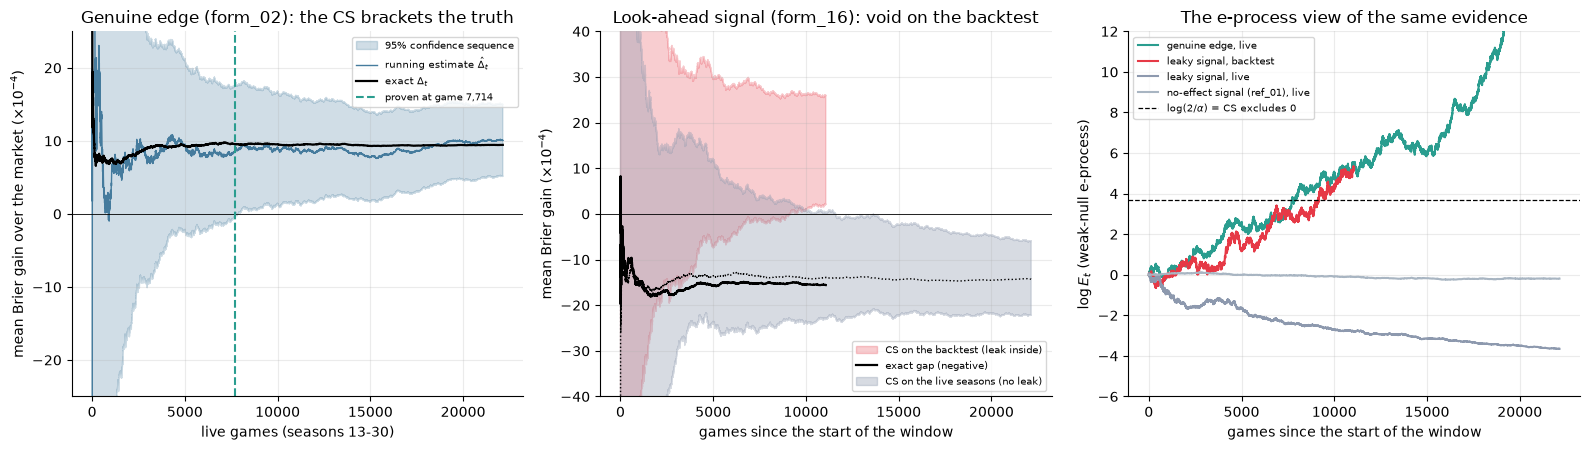

In [6]:
# Visualization only: uses `paths` and the showcase variables computed above.
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
p = paths["real_live"]; gx = np.arange(1, len(p["lo"]) + 1)
ax[0].fill_between(gx, 1e4 * p["lo"], 1e4 * p["up"], color=PALETTE["band"], alpha=0.25, label="95% confidence sequence")
ax[0].plot(gx, 1e4 * p["Dhat"], color=PALETTE["band"], lw=1, label=r"running estimate $\hat\Delta_t$")
ax[0].plot(gx, 1e4 * p["Dexact"], color="k", lw=1.6, label=r"exact $\Delta_t$")
ax[0].axhline(0, color="k", lw=0.6)
if first_cs["real_live"]:
    ax[0].axvline(first_cs["real_live"], color=PALETTE["real"], ls="--", label=f"proven at game {first_cs['real_live']:,}")
ax[0].set_ylim(-25, 25); ax[0].set_xlabel("live games (seasons 13-30)"); ax[0].set_ylabel(r"mean Brier gain over the market ($\times10^{-4}$)")
ax[0].set_title(f"Genuine edge ({NAMES[REAL]}): the CS brackets the truth"); ax[0].legend(fontsize=7.5, loc="upper right")
pb, pl = paths["leak_bt"], paths["leak_live"]
gb, gl = np.arange(1, len(pb["lo"]) + 1), np.arange(1, len(pl["lo"]) + 1)
ax[1].fill_between(gb, 1e4 * pb["lo"], 1e4 * pb["up"], color=PALETTE["leaky"], alpha=0.25, label="CS on the backtest (leak inside)")
ax[1].plot(gb, 1e4 * pb["Dexact"], color="k", lw=1.6, label="exact gap (negative)")
ax[1].fill_between(gl, 1e4 * pl["lo"], 1e4 * pl["up"], color=PALETTE["null"], alpha=0.35, label="CS on the live seasons (no leak)")
ax[1].plot(gl, 1e4 * pl["Dexact"], color="k", lw=1.0, ls=":")
ax[1].axhline(0, color="k", lw=0.6); ax[1].set_ylim(-40, 40)
ax[1].set_xlabel("games since the start of the window"); ax[1].set_ylabel(r"mean Brier gain ($\times10^{-4}$)")
ax[1].set_title(f"Look-ahead signal ({NAMES[LEAK]}): void on the backtest"); ax[1].legend(fontsize=7.5, loc="lower right")
for key, lab, col, ls in (("real_live", "genuine edge, live", PALETTE["real"], "-"), ("leak_bt", "leaky signal, backtest", PALETTE["leaky"], "-"),
                          ("leak_live", "leaky signal, live", PALETTE["null"], "-"), ("null_live", f"no-effect signal ({NAMES[NULL]}), live", PALETTE["proxy_null"], "-")):
    ax[2].plot(np.arange(1, len(paths[key]["le"]) + 1), paths[key]["le"], color=col, ls=ls, label=lab)
ax[2].axhline(np.log(2 / ALPHA_CS), color="k", ls="--", lw=0.9, label=r"$\log(2/\alpha)$ = CS excludes 0")
ax[2].set_ylim(-6, 12); ax[2].set_xlabel("games since the start of the window"); ax[2].set_ylabel(r"$\log E_t$ (weak-null e-process)")
ax[2].set_title("The e-process view of the same evidence"); ax[2].legend(fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()

**How to read this chart** *(cost of proof; two panels; 200 worlds)*

*Left.* The x-axis is the number of live games; the y-axis is the share of signal-worlds in which the 95% confidence sequence has already excluded zero from below, by hidden class. The genuine edges (teal, blue) climb slowly: after one live season essentially none is proven, after 12 seasons (about 14,800 games) between 28% and 79% of the four real edges (depending on the size of the edge), and by 18 seasons between 45% and 92%. The sub-vig edge (yellow) is too small to be proven within the horizon, no-effect signals and the decaying signal stay at zero as they should. The vertical dashed line is the horizon of about 10,000 games at which the paper's MLB confidence sequence first excluded zero (a much larger edge, on real data). *Right.* The distribution of $\log E$ after the 12 certification seasons, by class: a stage-2 e-value must clear the e-LOND threshold $\log(K'/\alpha)$ for a shortlist of size $K'$ (dashed lines for $K'=2$ and $K'=8$), so only the upper tail of the genuine edges qualifies. For the project: *proof is a slow product*. At these effect sizes a subscription business would be selling signals whose certificate arrives after years of live games; the pipeline's job is to make sure nothing false is sold in the meantime, and the registry of section 4 is what makes that possible.

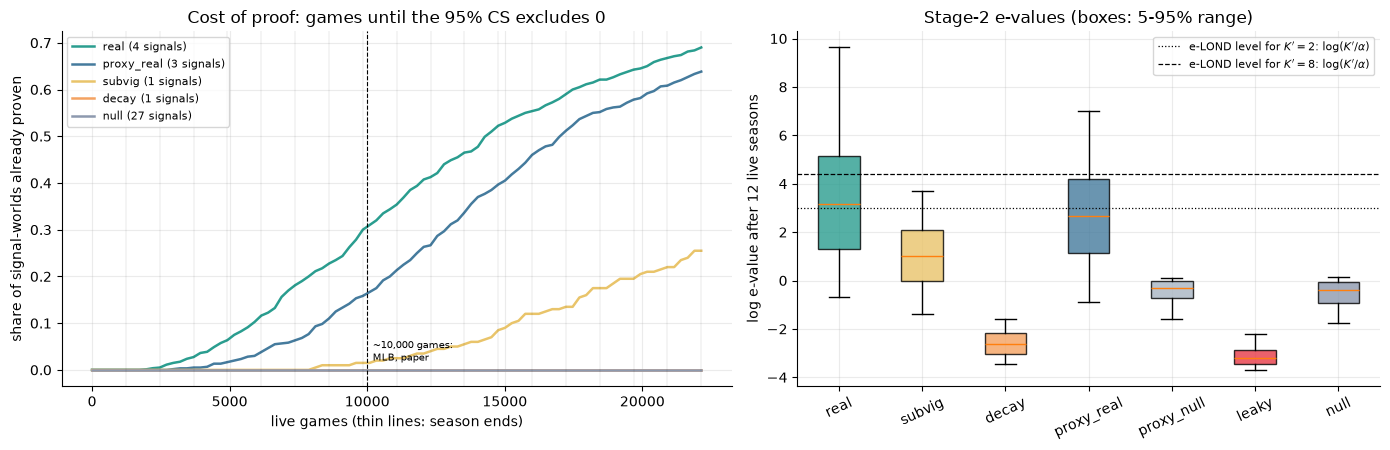

In [7]:
# Visualization only: uses A, CLS, cost_tab computed above.
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw=dict(width_ratios=[1.15, 1]))
grid = np.arange(0, 22141, 246)
for c_ in ["real", "proxy_real", "subvig", "decay", "null"]:
    f = A["first_cert"][:, CLS == c_].ravel()
    share = np.array([((f >= 0) & (f < g)).mean() for g in grid])
    ax[0].plot(grid, share, color=PALETTE[c_], lw=1.8, label=f"{c_} ({(CLS == c_).sum()} signals)")
ax[0].axvline(10000, color="k", ls="--", lw=0.8); ax[0].text(10200, 0.02, "~10,000 games:\nMLB, paper", fontsize=7.5)
for s in range(1, 19):
    ax[0].axvline(1230 * s, color="k", lw=0.2, alpha=0.3)
ax[0].set_xlabel("live games (thin lines: season ends)"); ax[0].set_ylabel("share of signal-worlds already proven")
ax[0].set_title("Cost of proof: games until the 95% CS excludes 0"); ax[0].legend(fontsize=8)
data = [A["logE_L"][:, L_GRID.index(12), CLS == c_].ravel() for c_ in CLASS_ORDER]
bp = ax[1].boxplot(data, patch_artist=True, showfliers=False, whis=(5, 95))
for patch, c_ in zip(bp["boxes"], CLASS_ORDER):
    patch.set_facecolor(PALETTE[c_]); patch.set_alpha(0.8)
ax[1].set_xticks(np.arange(1, len(CLASS_ORDER) + 1)); ax[1].set_xticklabels(CLASS_ORDER, rotation=25)
for kk, ls in ((2, ":"), (8, "--")):
    ax[1].axhline(np.log(kk / ALPHA_FDR), color="k", ls=ls, lw=0.9, label=fr"e-LOND level for $K'={kk}$: $\log(K'/\alpha)$")
ax[1].set_ylabel("log e-value after 12 live seasons"); ax[1].set_title("Stage-2 e-values (boxes: 5-95% range)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Screen: a registry that controls the false-discovery rate and survives the look-ahead bug

**What the paper gives (Xu and Ramdas, *Online multiple testing with e-values*).** Hypotheses $H_1,H_2,\dots$ arrive in a stream, each with an e-value $E_t\ge0$ satisfying $\mathbb E[E_t]\le1$ under the null (Eq. 3). Given a discount sequence $\gamma_t\ge0$ with $\sum\gamma_t\le1$, **e-LOND** tests $H_t$ at level $\alpha_t=\alpha\gamma_t(|R_{t-1}|+1)$ and discovers it when $E_t\ge1/\alpha_t$ (Sec. 3.2). **Theorem 1:** $\mathrm{FDR}(R_t)\le\alpha$ for every $t$ *under arbitrary dependence of the e-values*, and e-LOND strictly dominates r-LOND applied to $1/E_t$. The proof needs only the marginal bound $\mathbb E[E_i]\le1$ (through $\mathbf 1\{E\ge\alpha^{-1}\}\le\alpha E$, Eq. 6), which is why signals that reuse the same games are covered (Sec. 2, doubly sequential inference). A stopped e-process is an e-value (Eq. 4), so the Choe-Ramdas e-values of section 3, stopped at the end of a window, are valid inputs. The paper's simulations use $\gamma_t=1/(t(t+1))$ (App. B); the price of robustness is power (Sec. 5 and 7: e-LOND is beaten by dependence-specific methods when the dependence is known and mild), and the FDR guarantee is sharp (App. C, Thm 6). The traces do not address a *data-dependent* order of hypotheses, so the order below is the fixed registration order (signal id).

**Four registries compared (derived here).**

| Registry | Data used for the e-values | Procedure |
|---|---|---|
| naive (Notebook 2) | backtest | one-sided test at $p<0.05$ per signal, no correction, no predictability check |
| **single-stage** | backtest | e-LOND at $\alpha=0.10$ over the 40 signals in id order |
| **two-stage (the registry)** | stage 1: backtest; stage 2: **live seasons 13-24** | stage 1 shortlists signals whose backtest e-value is at least $e$; stage 2 runs e-LOND at $\alpha=0.10$ in id order on the *fresh live* e-values of the shortlist only |

*Why two stages.* The leaky signal is not predictable on the backtest, so the FDR guarantee is void for it there (its backtest e-value has mean about $2\times10^5$ in the audit, section 3). Sample splitting removes the problem: stage 1 may be wrong about anything, it only proposes; every signal must then earn its place on data that are causal, and the FDR guarantee of stage 2 holds conditionally on the shortlist because e-value validity is conditional on the past (Eq. 23). The shortlist also cuts the multiplicity that stage 2 pays for, from 40 hypotheses to about six. Stage 1 is a plain e-value threshold, not an e-LOND discovery step: a shortlist needs recall, not error control (a screen, not a discovery procedure: nothing about FDR is claimed for it).

**Discount sequence (derived here).** With the paper's $\gamma_t=1/(t(t+1))$ the level of the $t$-th hypothesis before any discovery is $\alpha/(t(t+1))$, which is $\alpha/1640$ at $t=40$ against a flat $\alpha/40$; the sequence favours signals registered early and starves late ones. Over a shortlist of $K'$ signals the flat sequence $\gamma_t=1/K'$ (derived here; it sums to one) gives every shortlisted signal the same level $\alpha/K'$. The audit reports both. On the certification window the default sequence gives slightly more power to the early-registered real edges and much less to the late-registered ones, and the flat sequence publishes more signals in total; the flat one is used for the registry because signal ids carry no prior about quality, so no position should be favoured (the table below gives the numbers behind both statements).

**Truth for the false-discovery proportion.** Three definitions are reported, in this order of strictness: (i) **window truth** (the primary one, the same labelling as the Notebook 2 audit): a signal is a true edge iff its exact expected Brier gap over the market is positive on the window in which it was certified (backtest for the single-stage registry, the 12 live seasons for the two-stage registry); (ii) **weak-null truth with a one-season burn-in**: the weak null $H_0^w$ of Eq. 18, $\Delta_t\le0$ for all $t$, is false if the exact running mean $\Delta_t$ is positive at some $t\ge1{,}230$; (iii) **weak-null truth to the letter** ($t\ge1$). The decaying signal has $\Delta_t>0$ early in the window, so it is *non-null* in the weak-null sense even though its full-window gap is negative; and by the letter of Eq. 18 nearly every no-effect signal is non-null too, because the first few exact per-game gaps of a null forecaster have random sign. Both weak-null variants therefore give *smaller* false-discovery proportions than the window truth, which is why the window truth is the headline number.

In [8]:
t0 = time.time()
iL = L_GRID.index(CERT_L)
short = shortlist_stage1(A["logE_bt"])                                     # (200, 40) stage-1 shortlists
pub_two_default = np.array([registry_stage2(A["logE_L"][i, iL], short[i], flat=False) for i in range(N_WORLDS)])
DESIGNS = {   # name -> (published mask, truth arrays of the window the design certifies on)
    "naive (Notebook 2)":          (A["naive_sel"].astype(bool), A["gap_bt"], A["wk_bt"], A["wk1_bt"]),
    "single-stage, default gamma": (A["pub_single_default"].astype(bool), A["gap_bt"], A["wk_bt"], A["wk1_bt"]),
    "single-stage, flat gamma":    (A["pub_single_flat"].astype(bool), A["gap_bt"], A["wk_bt"], A["wk1_bt"]),
    "two-stage, default gamma":    (pub_two_default, A["gap_L"][:, iL], A["wk_L"][:, iL], A["wk1_L"][:, iL]),
    "two-stage, flat gamma (registry)": (A["pub_two"].astype(bool), A["gap_L"][:, iL], A["wk_L"][:, iL], A["wk1_L"][:, iL]),
}
def fdp_of(pub, truth_pos):
    npub = pub.sum(1)
    return np.where(npub > 0, (pub & ~truth_pos).sum(1) / np.maximum(npub, 1), 0.0)
REG = {}
for name, (pub, gap, wk, wk1) in DESIGNS.items():
    fdp_w, fdp_k, fdp_l = fdp_of(pub, gap > 0), fdp_of(pub, wk > 0), fdp_of(pub, wk1 > 0)
    lk = int(pub[:, IS_LEAKY].sum())
    REG[name] = dict(pub_per_world=pub.sum(1).mean(), worlds_ge1=(pub.sum(1) > 0).mean(), fdp=fdp_w, fdp_weak=fdp_k, fdp_letter=fdp_l, leaky=lk,
                     power={c_: pub[:, CLS == c_].mean() for c_ in ["real", "proxy_real", "subvig"]})
rows = []
for name, R in REG.items():
    m, lo, hi = boot_ci(R["fdp"])
    lw = wilson(R["leaky"], N_WORLDS)
    rows.append({"registry": name, "published / world": round(R["pub_per_world"], 2), "worlds with >= 1": round(R["worlds_ge1"], 3),
                 "FDP window truth [95% boot]": f"{m:.3f} [{lo:.3f}, {hi:.3f}]", "FDP weak-null (burn-in)": round(R["fdp_weak"].mean(), 3),
                 "FDP weak-null (letter)": round(R["fdp_letter"].mean(), 3),
                 "leaky published [Wilson]": f"{R['leaky'] / N_WORLDS:.3f} [{lw[0]:.3f}, {lw[1]:.3f}]",
                 "power real": round(R["power"]["real"], 3), "power proxy_real": round(R["power"]["proxy_real"], 3), "power subvig": round(R["power"]["subvig"], 3)})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nstage 1: shortlist size {short.sum(1).mean():.2f} signals per world; recall of real / proxy_real / subvig edges "
      f"{short[:, CLS == 'real'].mean():.2f} / {short[:, CLS == 'proxy_real'].mean():.2f} / {short[:, CLS == 'subvig'].mean():.2f}; "
      f"leaky shortlisted in {short[:, IS_LEAKY].mean():.3f} of worlds; no-effect signals shortlisted per world {short[:, CLS == 'null'].sum(1).mean():.3f}")

# cost-of-proof curve of the registry: two-stage, flat gamma, at each pre-specified live horizon (each horizon is a separate, pre-specified registry)
CURVE = []
for i, L in enumerate(L_GRID):
    pub = np.array([registry_stage2(A["logE_L"][w, i], short[w]) for w in range(N_WORLDS)])
    CURVE.append(dict(L=L, games=1230 * L, pub_per_world=pub.sum(1).mean(), fdp=fdp_of(pub, A["gap_L"][:, i] > 0).mean(),
                      leaky=pub[:, IS_LEAKY].mean(), **{f"power_{c_}": pub[:, CLS == c_].mean() for c_ in ["real", "proxy_real", "subvig"]}))
curve = pd.DataFrame(CURVE)
print("\nTwo-stage registry by certification horizon (each row is its own pre-specified registry):")
print(curve.round(3).to_string(index=False))

# SELF-CHECKs
R2 = REG["two-stage, flat gamma (registry)"]; m2, lo2, hi2 = boot_ci(R2["fdp"])
check("e-LOND guarantee (Thm 1): two-stage registry, mean false-discovery proportion over 200 worlds, window truth [95% bootstrap]", f"{m2:.3f} [{lo2:.3f}, {hi2:.3f}]",
      f"upper end <= alpha = {ALPHA_FDR}", hi2 <= ALPHA_FDR)
check("e-LOND guarantee under the weak-null truth (burn-in): two-stage registry, mean FDP", f"{R2['fdp_weak'].mean():.3f}", f"<= {ALPHA_FDR}", R2["fdp_weak"].mean() <= ALPHA_FDR)
Rs = REG["single-stage, flat gamma"]; lw_s = wilson(Rs["leaky"], N_WORLDS)
check("the look-ahead signal passes the single-stage (backtest-only) registry: share of worlds in which it is published [Wilson]",
      f"{Rs['leaky'] / N_WORLDS:.3f} [{lw_s[0]:.3f}, {lw_s[1]:.3f}]", "lower end > 0.01 (the leak gets through)", lw_s[0] > 0.01)
check("stage 1 shortlists the leaky signal almost always (which is why stage 2 must judge it on live data): share of worlds", f"{short[:, IS_LEAKY].mean():.3f}", ">= 0.9", short[:, IS_LEAKY].mean() >= 0.9)
check("the same naive screen applied to these 200 worlds reproduces the Notebook 2 audit (mean FDP vs 0.187, leaky published vs 0.955)",
      f"{REG['naive (Notebook 2)']['fdp'].mean():.3f}, {REG['naive (Notebook 2)']['leaky'] / N_WORLDS:.3f}", "FDP in [0.15, 0.23] and leaky >= 0.9",
      0.15 <= REG['naive (Notebook 2)']['fdp'].mean() <= 0.23 and REG['naive (Notebook 2)']['leaky'] / N_WORLDS >= 0.9)
print(f"(cell time {time.time() - t0:.1f}s)")

                        registry  published / world  worlds with >= 1 FDP window truth [95% boot]  FDP weak-null (burn-in)  FDP weak-null (letter) leaky published [Wilson]  power real  power proxy_real  power subvig
              naive (Notebook 2)               7.46             1.000        0.189 [0.178, 0.200]                    0.155                   0.046     0.955 [0.917, 0.976]       0.786             0.750         0.555
     single-stage, default gamma               0.38             0.310        0.098 [0.062, 0.139]                    0.098                   0.049     0.125 [0.086, 0.178]       0.064             0.002         0.000
        single-stage, flat gamma               1.08             0.695        0.360 [0.301, 0.419]                    0.360                   0.122     0.495 [0.426, 0.564]       0.114             0.042         0.000
        two-stage, default gamma               1.96             0.895        0.000 [0.000, 0.000]                    0.000              

**How to read this chart** *(four panels; 200 worlds)*

*Top left: false-discovery proportion by registry* (mean over worlds, bars with 95% bootstrap intervals, window truth); the dashed line is the AC1 target of 10%. *Top right: how often the look-ahead signal is published* (bars, Wilson intervals); the dashed line is the AC2 target of 1%. The naive registry publishes the bug almost always; a backtest-only e-LOND publishes it in a large share of worlds when the discount sequence is flat, because the e-value of a signal whose forecasts contain the outcome is enormous; only the stage that looks at causal data removes it. *Bottom left: power by class* (share of the class's signals published): the price of the guarantee. The naive screen publishes about three quarters of the genuine edges (and the bug in 96% of worlds); the two-stage registry publishes roughly a third of the real edges and of the proxy-real ones, and almost never the sub-vig edge. *Bottom right: the registry's power as the certification horizon grows* (each point is a separate pre-specified registry: 3, 6, 9 or 12 live seasons): published signals per world and the share of real and proxy-real edges published. Power is small at the horizon where a live product would want an answer and grows only with the square root of the games. For the project: the guarantee is what the client asked for (a registry it can defend), and its cost is that most genuine small edges stay *unproven* for a long time; the notebook does not hide this behind a laxer level.

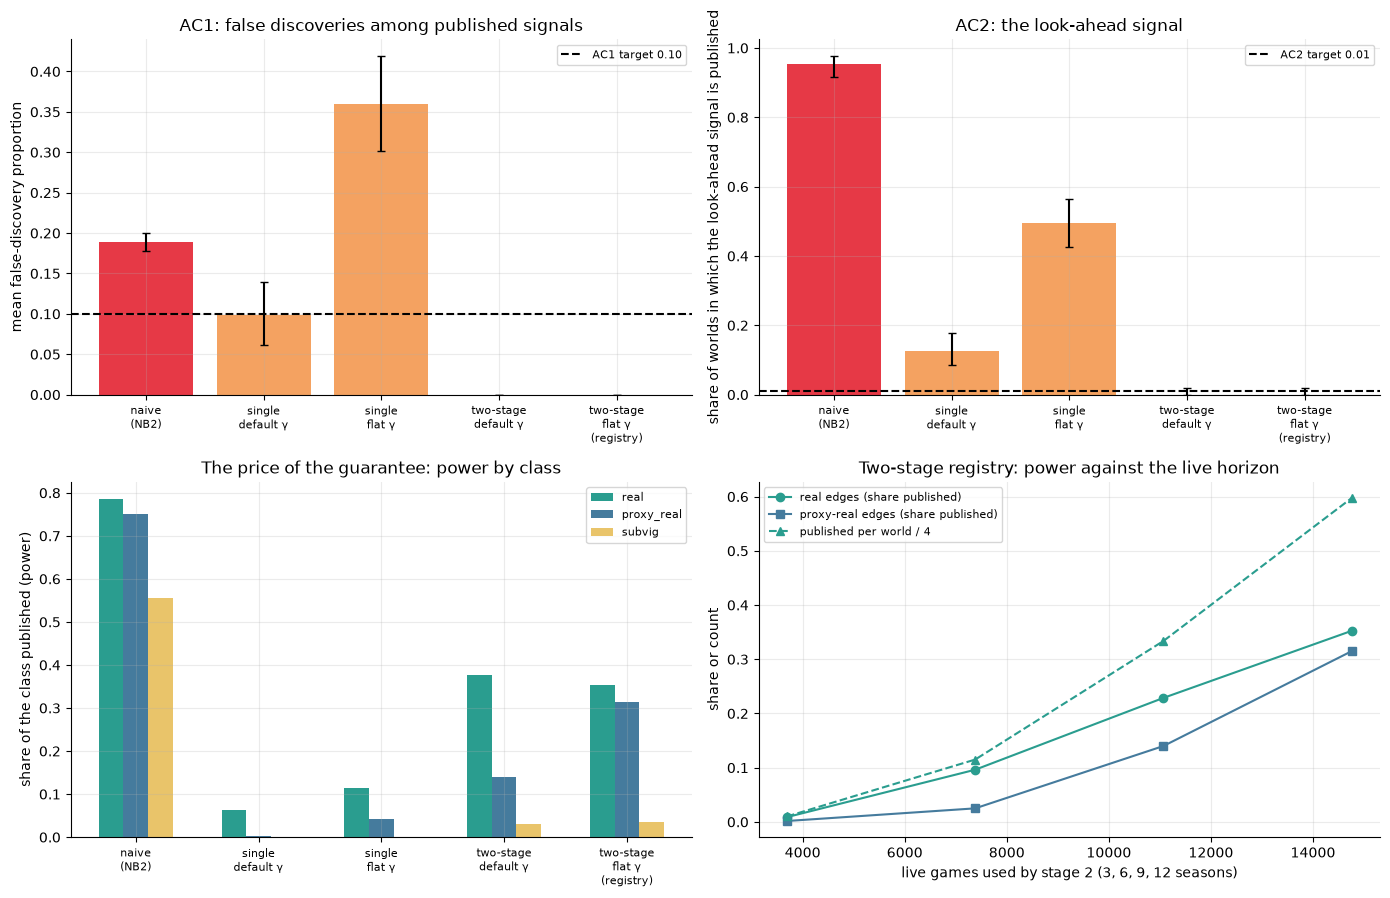

In [9]:
# Visualization only: uses REG, curve, DESIGNS computed above.
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
names = list(REG.keys()); short_names = ["naive\n(NB2)", "single\ndefault γ", "single\nflat γ", "two-stage\ndefault γ", "two-stage\nflat γ\n(registry)"]
cols = [PALETTE["naive"], PALETTE["single"], PALETTE["single"], PALETTE["two_stage"], PALETTE["two_stage"]]
ci = [boot_ci(REG[n]["fdp"]) for n in names]
ax[0, 0].bar(range(5), [c[0] for c in ci], color=cols, yerr=[[c[0] - c[1] for c in ci], [c[2] - c[0] for c in ci]], capsize=3)
ax[0, 0].axhline(0.10, color="k", ls="--", label="AC1 target 0.10"); ax[0, 0].set_xticks(range(5)); ax[0, 0].set_xticklabels(short_names, fontsize=8)
ax[0, 0].set_ylabel("mean false-discovery proportion"); ax[0, 0].set_title("AC1: false discoveries among published signals"); ax[0, 0].legend(fontsize=8)
lk = [REG[n]["leaky"] for n in names]; wl = [wilson(k, N_WORLDS) for k in lk]
ax[0, 1].bar(range(5), [k / N_WORLDS for k in lk], color=cols, yerr=[[k / N_WORLDS - w[0] for k, w in zip(lk, wl)], [w[1] - k / N_WORLDS for k, w in zip(lk, wl)]], capsize=3)
ax[0, 1].axhline(0.01, color="k", ls="--", label="AC2 target 0.01"); ax[0, 1].set_xticks(range(5)); ax[0, 1].set_xticklabels(short_names, fontsize=8)
ax[0, 1].set_ylabel("share of worlds in which the look-ahead signal is published"); ax[0, 1].set_title("AC2: the look-ahead signal"); ax[0, 1].legend(fontsize=8)
w = 0.2
for j, c_ in enumerate(["real", "proxy_real", "subvig"]):
    ax[1, 0].bar(np.arange(5) + (j - 1) * w, [REG[n]["power"][c_] for n in names], w, color=PALETTE[c_], label=c_)
ax[1, 0].set_xticks(range(5)); ax[1, 0].set_xticklabels(short_names, fontsize=8); ax[1, 0].set_ylabel("share of the class published (power)")
ax[1, 0].set_title("The price of the guarantee: power by class"); ax[1, 0].legend(fontsize=8)
ax[1, 1].plot(curve["games"], curve["power_real"], "o-", color=PALETTE["real"], label="real edges (share published)")
ax[1, 1].plot(curve["games"], curve["power_proxy_real"], "s-", color=PALETTE["proxy_real"], label="proxy-real edges (share published)")
ax[1, 1].plot(curve["games"], curve["pub_per_world"] / 4, "^--", color=PALETTE["two_stage"], label="published per world / 4")
ax[1, 1].set_xlabel("live games used by stage 2 (3, 6, 9, 12 seasons)"); ax[1, 1].set_ylabel("share or count")
ax[1, 1].set_title("Two-stage registry: power against the live horizon"); ax[1, 1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Combine: one forecaster from the market and the certified signals

**What the paper gives (Chen, Huang, Jordan and Luo, *Calibeating Made Simple*).** In each round the learner sees $N$ external forecasts $q^{(n)}_t$, issues its own $p_t$, and then $y_t$ is revealed; forecasts and outcomes come from an **oblivious adversary**, fixed in advance (Sec. 2). The cumulative loss is $L_T$, the **refinement score** $R_T$ is the loss of an oracle that relabels every distinct forecast value by the best constant in hindsight, and $K_T=L_T-R_T$ is the calibration error (Def. 2.1; for the Brier loss, weighted within-bin variance and $\ell_2$-calibration, Ex. 2.2). A learner is *calibeating* if $L_T\le R_T(q)+\alpha(T)$ (Def. 2.4). **Algorithm 1** runs an independent no-regret copy per distinct forecast value and is $|Q|\,\alpha(T/|Q|)$-calibeating (**Thm 3.1**), where $|Q|$ is the number of distinct forecast values; for the mixable Brier loss the rate is $O(|Q|\log T)$ (Cor. 3.4) and cannot be improved (Thm 3.5, Cor. 3.7); follow-the-leader attains it. **Algorithm 2** calibeats each forecaster and aggregates the calibeated forecasts with Hedge: it is $(\alpha(T)+\gamma(T))$-multi-calibeating (Thm 4.1), $O(\log N+|Q|\log T)$ for a mixable loss (Cor. 4.3). **The paper has no experiments and no code**, and its guarantees are worst-case over fixed sequences, not statements about a particular market; it also says calibration alone cannot certify expertise.

**What we do with it (derived here).** A continuous forecast must be rounded to a finite grid: forecasts are placed in $|Q|=20$ equal-width bins of $[0,1]$, the in-bin learner is follow-the-leader (the running in-bin mean of the outcomes), Hedge uses $\eta=1/2$ (the exp-concavity constant of the scalar Brier loss, the setting of the exported `multi_calibeat`). The combined forecaster of deliverable D2 is a **Hedge pool** over

* the de-margined market $q$ and its calibeated version;
* for every signal that the two-stage registry has **published**: its (capped) forecast and its calibeated version.

The pool contains the **raw** market and the raw published forecasts next to their calibeated versions. That goes beyond Algorithm 2, which calibeats every expert; the reason is in the numbers below (a calibeated forecast loses the within-bin resolution of the forecast it rounds). The paper-pure variant, `multi_calibeat` over $[q,\ \text{published forecasts}]$, is reported next to it. Only published signals enter, so a signal that has not earned a certificate cannot reach a customer through the combination. The forecasters run online over seasons 4-30 (warm start on history: every input is predictable), and are **judged on the fresh seasons 25-30 only**, which the registry never used. For the interval, the combined forecast is capped to within $\pm0.08$ of the market (the same rule as for every registered forecaster, so Thm 2 holds ex ante with $c=0.32$); the interval is the 95% empirical-Bernstein confidence sequence of the Brier differential against the de-margined market, and **AC3 asks for its lower end to be at least $-0.0005$** (mean over worlds; the share of worlds meeting the bar is printed too).

**Compared with:** the market alone (differential exactly 0); the calibeated market alone; the naive stack of Notebook 2 (weights fitted on the backtest window, published set of the naive screen, leak included; capped in the same way); and the equal-weight average of the published signals' forecasts. **The planted longshot mispricing** (Notebook 2: the market's logit is $1/1.06$ of the true one) is the thing calibeating the market should be able to recover; the exact gain of a perfect price recalibration is computed for scale.

In [10]:
t0 = time.time()
VARIANTS = [("calq", "calibeated market alone"), ("multical", "multi-calibeat (paper-pure)"), ("hybrid", "combined forecaster (Hedge pool)"),
            ("published_only", "average of published signals"), ("naive_stack", "naive stack (Notebook 2)")]
rows = []
for key, lab in VARIANTS:
    g, lo, up = A[f"comb_{key}_gap"], A[f"comb_{key}_lower"], A[f"comb_{key}_upper"]
    gm = boot_ci(g); lm = boot_ci(lo)
    rows.append({"forecaster": lab, "exact gap vs market x1e4 [95% boot]": f"{1e4 * gm[0]:+.2f} [{1e4 * gm[1]:+.2f}, {1e4 * gm[2]:+.2f}]",
                 "CS lower end x1e4 (mean)": f"{1e4 * lm[0]:+.2f} [{1e4 * lm[1]:+.2f}, {1e4 * lm[2]:+.2f}]", "CS upper end x1e4 (mean)": f"{1e4 * up.mean():+.2f}",
                 "share of worlds with lower end >= -5e-4": round(float((lo >= -5e-4).mean()), 3),
                 "exact ROI, threshold rule (%)": round(100 * np.nanmean(A[f"comb_{key}_roi_edge"]), 2), "bets per 7,380 games": int(A[f"comb_{key}_nbets"].mean())})
print("Fresh live seasons 25-30 (7,380 games), mean over 200 worlds; the market alone has gap 0 and a degenerate interval:")
print(pd.DataFrame(rows).to_string(index=False))

# is the planted longshot mispricing recoverable by calibeating the market? (exact, on the fresh window)
gq, g_snap, g_orc, g_vs_snap = A["comb_calq_gap"], A["comb_snap_gap_vs_market"], A["oracle_price_gain"], A["comb_calq_gap_vs_snap"]
print("\nThe planted longshot mispricing (exact Brier gain x1e4 per game, fresh window, mean [95% boot] over worlds):")
for lab, arr in (("perfect price recalibration (oracle, derived here)", g_orc), ("market rounded to the 20-bin grid, vs raw market", g_snap),
                 ("calibeated market vs raw market", gq), ("calibeated market vs the ROUNDED market (the paper's reference is the refinement of the rounded forecast)", g_vs_snap)):
    m_, l_, h_ = boot_ci(arr); print(f"  {lab:105s} {1e4 * m_:+7.2f} [{1e4 * l_:+.2f}, {1e4 * h_:+.2f}]")

# theory check on the showcase world: calibeating regret against the refinement score grows logarithmically, not linearly (Cor. 3.4, Alg. 1 with FTL)
mh = sS >= 4
qh, yh = qS[mh], yS[mh]
calS = calibeat(qh, yh, nbins=NBINS)
binq = np.minimum(np.floor(np.clip(qh, 0, 1) * NBINS).astype(int), NBINS - 1)
L_T = ((calS - yh) ** 2).sum()
R_T = sum(((yh[binq == k] - yh[binq == k].mean()) ** 2).sum() for k in np.unique(binq))
Tn, Qn = len(yh), len(np.unique(binq))
bound = Qn * (1 + np.log(Tn / Qn))
check("calibeating regret against the refinement score of the grid-rounded market (showcase world, all 27 seasons): L_T - R_T against |Q|(1 + ln(T/|Q|)) (constant 1 is a generous derived-here choice; the paper gives the order O(|Q| log T))",
      f"{L_T - R_T:.1f} (per game {(L_T - R_T) / Tn:.1e}; T={Tn}, |Q|={Qn})", f"0 <= regret <= {bound:.0f}", 0 <= L_T - R_T <= bound)
# (cap check is done after the showcase hedge run below)
m_q, l_q, h_q = boot_ci(gq)
finding("planted mispricing recovered by calibeating the market alone? mean exact gap of the calibeated market over the raw market, fresh window (x1e-4) [95% bootstrap]",
      f"{1e4 * m_q:+.2f} [{1e4 * l_q:+.2f}, {1e4 * h_q:+.2f}] (oracle recalibration would gain {1e4 * g_orc.mean():+.2f})", "RECOVERED" if l_q > 0 else "NOT RECOVERED (rounding to the bin grid and the learning cost outweigh the planted effect)")
mh_, lh_, hh_ = boot_ci(A["comb_hybrid_gap"])
check("the combined forecaster is not worse than the market on the fresh window: mean exact gap (x1e-4) [95% bootstrap]", f"{1e4 * mh_:+.2f} [{1e4 * lh_:+.2f}, {1e4 * hh_:+.2f}]", "lower end > 0", lh_ > 0)

# showcase world: Hedge weights of the combined forecaster over time, grouped
pub_ids = np.where(A["pub_two"][SHOW_I])[0]
cols = [qh, calS]; grp = ["market (raw)", "market (calibeated)"]
for j in pub_ids:
    cols += [PS[mh, j], calibeat(PS[mh, j], yh, nbins=NBINS)]; grp += ["published (raw)", "published (calibeated)"]
hybS, wtsS = hedge_mix(np.stack(cols, 1), yh)
grp = np.array(grp)
wgrp = {g: wtsS[:, grp == g].sum(1) for g in ["market (raw)", "market (calibeated)", "published (raw)", "published (calibeated)"]}
ev_show = (sS[mh] >= EVAL_FIRST)
cap_share = float((np.abs(hybS - qh)[ev_show] > KAPPA).mean())
check("the +-0.08 cap on the combined forecast binds in a small share of evaluation games (showcase world, uncapped Hedge output); for scale, the uncapped calibeated market alone deviates from the market by up to "
      + f"{A['comb_calq_maxdev'].max():.2f} in the audit (early, sparsely filled bins)", f"{100 * cap_share:.3f}% of games", "< 1%", cap_share < 0.01)
print(f"\nshowcase world: {len(pub_ids)} published signals ({', '.join(NAMES[i] for i in pub_ids)}); hedge weights at the start of the fresh window: "
      + ", ".join(f"{g} {wgrp[g][np.where(sS[mh] >= EVAL_FIRST)[0][0]]:.2f}" for g in wgrp))
print(f"(cell time {time.time() - t0:.1f}s)")

Fresh live seasons 25-30 (7,380 games), mean over 200 worlds; the market alone has gap 0 and a degenerate interval:
                      forecaster exact gap vs market x1e4 [95% boot] CS lower end x1e4 (mean) CS upper end x1e4 (mean)  share of worlds with lower end >= -5e-4  exact ROI, threshold rule (%)  bets per 7,380 games
         calibeated market alone                -3.05 [-3.12, -2.99]  -10.71 [-10.96, -10.45]                    +4.92                                    0.005                          -5.01                  1680
     multi-calibeat (paper-pure)                +5.65 [+5.11, +6.15]     -5.46 [-6.00, -4.92]                   +17.72                                    0.475                           1.60                  3292
combined forecaster (Hedge pool)                +8.39 [+7.90, +8.86]     -0.93 [-1.41, -0.44]                   +18.49                                    0.910                           4.97                  2517
    average of published signals

SELF-CHECK 18: the combined forecaster is not worse than the market on the fresh window: mean exact gap (x1e-4) [95% bootstrap] -> +8.39 [+7.90, +8.86] (threshold lower end > 0) -> MET
SELF-CHECK 19: the +-0.08 cap on the combined forecast binds in a small share of evaluation games (showcase world, uncapped Hedge output); for scale, the uncapped calibeated market alone deviates from the market by up to 0.92 in the audit (early, sparsely filled bins) -> 0.000% of games (threshold < 1%) -> MET

showcase world: 6 published signals (ref_04, rest_10, form_02, form_10, form_11, form_12); hedge weights at the start of the fresh window: market (raw) 0.00, market (calibeated) 0.00, published (raw) 1.00, published (calibeated) 0.00
(cell time 0.6s)


**How to read this chart** *(three panels; fresh seasons 25-30)*

*Left: exact mean Brier gain over the market* (units of $10^{-4}$, bars with 95% bootstrap intervals over the 200 worlds; positive is better than the market). The calibeated market alone is **worse** than the raw market: calibeating rounds the market to 20 values and pays a learning cost per value, and together these exceed the tiny planted mispricing (the exact value of a perfect price recalibration is only about $7\times10^{-5}$ per game, dotted line, while rounding the market to the 20-value grid alone costs about $2\times10^{-4}$; see the printed table). The paper-pure multi-calibeat inherits that handicap; the Hedge pool that keeps the raw market and the raw published forecasts next to their calibeated versions lands well above zero, because it can put its weight on whichever expert has been doing best. The naive stack has the largest gain, since it uses about seven signals (the genuine edges among them) instead of the two or so that have been *proven*. *Middle: the AC3 statistic.* Each box is the distribution over worlds of the lower end of the 95% confidence sequence; the dashed line is the AC3 bar of $-0.0005$. A forecaster that stays close to the market has a narrow interval (its differential has small variance), one that wanders has a wide one. *Right: the Hedge weights of the combined forecaster in the showcase world*, by group of experts, over the 27 seasons of the online run; the vertical line is the start of the fresh evaluation window. The calibeated experts lose their weight in the first games because every bin learner starts from scratch (an empty bin predicts 0.5), and the published raw forecasts then dominate the raw market. For the project: combining is where *proof and profit trade off*: the certified pool is safe and honest but smaller than what an unproven stack would deliver, and calibeating on its own does not find the planted mispricing at this data size.

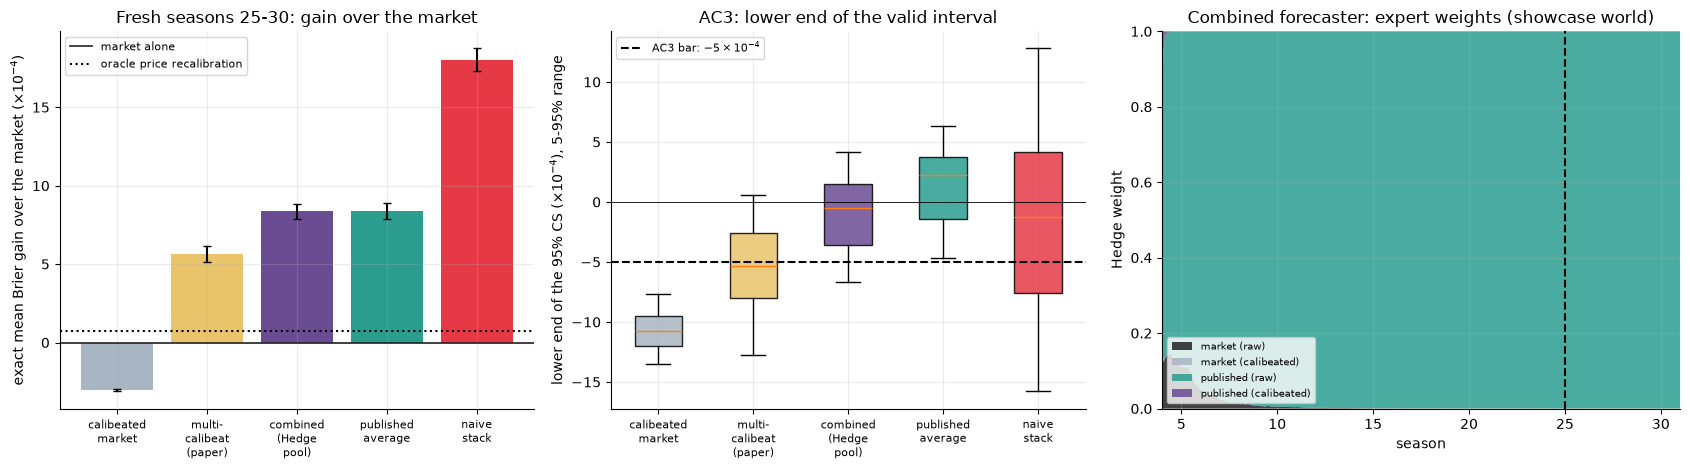

In [11]:
# Visualization only: uses A, VARIANTS, wgrp, sS computed above.
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw=dict(width_ratios=[1.1, 1.1, 1.2]))
labs = ["calibeated\nmarket", "multi-\ncalibeat\n(paper)", "combined\n(Hedge\npool)", "published\naverage", "naive\nstack"]
colv = [PALETTE["proxy_null"], PALETTE["subvig"], PALETTE["combined"], PALETTE["two_stage"], PALETTE["naive"]]
cis = [boot_ci(A[f"comb_{k}_gap"]) for k, _ in VARIANTS]
ax[0].bar(range(5), [1e4 * c[0] for c in cis], color=colv, yerr=[[1e4 * (c[0] - c[1]) for c in cis], [1e4 * (c[2] - c[0]) for c in cis]], capsize=3)
ax[0].axhline(0, color=PALETTE["market"], lw=1.2, label="market alone"); ax[0].axhline(1e4 * A["oracle_price_gain"].mean(), color="k", ls=":", label="oracle price recalibration")
ax[0].set_xticks(range(5)); ax[0].set_xticklabels(labs, fontsize=8); ax[0].set_ylabel(r"exact mean Brier gain over the market ($\times10^{-4}$)")
ax[0].set_title("Fresh seasons 25-30: gain over the market"); ax[0].legend(fontsize=8)
bp = ax[1].boxplot([1e4 * A[f"comb_{k}_lower"] for k, _ in VARIANTS], patch_artist=True, showfliers=False, whis=(5, 95))
for patch, c in zip(bp["boxes"], colv):
    patch.set_facecolor(c); patch.set_alpha(0.85)
ax[1].axhline(-5, color="k", ls="--", label="AC3 bar: $-5\\times10^{-4}$"); ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_xticks(range(1, 6)); ax[1].set_xticklabels(labs, fontsize=8); ax[1].set_ylabel(r"lower end of the 95% CS ($\times10^{-4}$), 5-95% range")
ax[1].set_title("AC3: lower end of the valid interval"); ax[1].legend(fontsize=8)
xg = np.arange(len(sS[mh])) / 1230.0 + 4
ax[2].stackplot(xg, [wgrp[g] for g in wgrp], labels=list(wgrp.keys()), colors=[PALETTE["market"], PALETTE["proxy_null"], PALETTE["two_stage"], PALETTE["combined"]], alpha=0.85)
ax[2].axvline(EVAL_FIRST, color="k", ls="--"); ax[2].set_xlim(4, 31); ax[2].set_ylim(0, 1)
ax[2].set_xlabel("season"); ax[2].set_ylabel("Hedge weight"); ax[2].set_title("Combined forecaster: expert weights (showcase world)"); ax[2].legend(fontsize=7.5, loc="lower left")
plt.tight_layout(); plt.show()

## 6. Monitor: flagging an edge that has stopped working

**The problem.** The decaying signal of Notebook 2 has a real edge through season 4 and none afterwards, but its frozen forecaster keeps betting on it, so from season 5 on its exact expected gap against the market is about $-8\times10^{-4}$ per game. A confidence sequence for $\Delta_t$ from the start of the record targets the average over *the whole history*, pre-decay era included, so it moves slowly: the decay has to overwhelm the good years before the interval reacts.

**What the paper allows.** Choe and Ramdas Appendix F.1 gives inference for a **predictable subsequence**: for indicators $\xi_i$ that are predictable (fixed *before* game $i$ is played), the target is $\Delta_t(\xi)=\sum_i\xi_i\delta_i/\sum_i\xi_i$ (Eq. 96) and the products over $\{i:\xi_i=1\}$ of the per-game exponential terms form a test supermartingale (Eq. 97-100) and an e-process (Eq. 101-102). In words: one may test "the last three seasons only" **if that rule is fixed in advance**. The direction is the mirror image of section 3: reject $H_0^w(q,p)$ ("the market is no better than the signal") when the *market-is-better* e-process is large, equivalently when a confidence sequence has upper end below 0 (Cor. 1, Eq. 19). The papers do not cover a subsequence chosen *after* looking at the data; they also state that all guarantees are descriptive, not predictive (Choe and Ramdas, Sec. 5.2 and 6).

**Four monitors compared** (launch at the start of season 4; decisions at the end of every season or, where noted, after every game; *derived here* unless a paper location is given):

| Monitor | Rule | Valid? |
|---|---|---|
| **dashboard** (the client's habit) | a fixed-time 95% $z$-interval of the mean gap since launch, refreshed after every game; alarm when its upper end falls below 0 | **no**: peeking at a fixed-time interval inflates errors (Notebook 1, section 2) |
| **full-history CS** | the two-sided 90% confidence sequence of Thm 2 since launch (a one-sided 5% test; `ALPHA_MON`), checked after every game; alarm when the upper end is below 0 | yes, anytime-valid (Eq. 2-3), no multiplicity cost |
| **block monitor** | at the end of every season $j\ge5$, the market-is-better e-process on the games of the trailing three seasons (App. F.1, $\xi$ fixed in advance); alarm when $E\ge1/(\alpha\gamma_k)$ with $\gamma_k=1/(k(k+1))$, $k=j-4$ | yes, by the union bound over checkpoints (each has its own e-value; the discount sequence spends $\alpha=0.05$ once) |
| **restart-at-the-worst-looking-start (the trap)** | at the end of every season, take the block start that looks worst *after seeing the data* (candidate starts every half season since launch) and alarm when its market-is-better e-process reaches the nominal single-test threshold $2/\alpha=40$ | **no**: it tests a hypothesis about a block chosen from the outcomes, which the guarantee does not cover |

**Scoring AC4 (Notebook 2 as written, and a revised horizon).** The decay onset is the start of season 5. A monitor *flags in time* if it alarms within a given number of games after the onset; false alarms are counted per (world, non-decaying genuine edge) over the whole record of 27 seasons (the eight stable edges of the truth table) and must be at most 5%. Notebook 2 does not give a required detection rate; we score AC4 as met only if the decay is flagged in time in **at least half of the worlds** *and* the false-alarm rate is at most 5%. Two horizons are scored: **3,690 games, as written in Notebook 2**, and **14,760 games (12 seasons), the revised horizon**.

**Why the horizon is revised, and the order of the choices (all disclosed).** The arithmetic below shows that 3,690 games is at the ceiling of what an oracle test could reach, so no valid sequential monitor can meet it; a monitor that is required to be valid needs a longer window. The revised horizon is the 12 seasons of the certification window, so that a decaying edge is expected to be *flagged* within the same span in which a genuine edge is *certified* (a consistency rule, not an optimum). The order was: (1) the monitor's design constants were compared on prototype worlds 900-959, which are disjoint from the audit; (2) a first 200-world audit with the previous monitor level (a 95% sequence, which spends only 2.5% of the 5% false-alarm budget) flagged 0.480 of the worlds within 14,760 games; (3) because the observed false-alarm rate was 0.06% against a 5% allowance, the monitor's level was raised to the full one-sided 5% (`ALPHA_MON`), a change that leaves the monitor anytime-valid, and it was checked on 60 more prototype worlds (0.583 within 14,760 games against 0.517 at the old level) before (4) the audit was re-run once with the new level, which is the audit printed here. The horizon was not moved between the audits. The written-horizon result is reported unchanged next to it.

**Why detection is slow (derived here).** For the decaying forecaster the per-game gap is about $-8\times10^{-4}$ and the per-game standard deviation of the score differential is about 0.03, so the $z$-statistic of a block of $n$ post-onset games is about $0.027\sqrt{n}$: after 3,690 games it is about 1.6, which even an oracle fixed-time test at the 5% level would reach in only about half of the worlds. No valid sequential method can beat that bound by much, and anytime validity, alpha-spending over checkpoints and the conservative empirical-Bernstein mixture all cost more.

In [12]:
t0 = time.time()
GPS = 1230
onset = GPS                                     # 0-based game index (since launch) of the first game of season 5
dec_i = np.where(IS_DECAY)[0][0]
edge_ids = np.where(STABLE_EDGE)[0]
def after_onset_from_game(idx):                 # game-resolution monitors: idx = 0-based first alarm game since launch (-1: never)
    return np.where(idx >= 0, idx - onset + 1, np.nan)
def after_onset_from_season(al, sig):           # season-end monitors: al (worlds, 31, 40) bool over checkpoint seasons j
    j = np.where(al.any(axis=1), np.argmax(al, axis=1), -1)[:, sig]
    return np.where(j >= 0, (j - 4) * GPS, np.nan)
MON = {
    "dashboard (fixed-time z-interval, every game)": (A["first_dash"], "game"),
    "full-history CS (every game)": (A["first_full"], "game"),
    "block monitor (trailing 3 seasons, alpha-spent)": (A["blk_alarm"].astype(bool), "season"),
    "restart at worst-looking start (TRAP)": (A["trap_alarm"].astype(bool), "season"),
}
def alarm_times(mon, sig):
    arr, kind = mon
    return after_onset_from_game(arr[:, sig]) if kind == "game" else after_onset_from_season(arr, sig)
def false_alarm_flags(mon):                     # (worlds, 8 stable edges): any alarm ever
    arr, kind = mon
    return (arr[:, edge_ids] >= 0) if kind == "game" else arr.any(axis=1)[:, edge_ids]
rows, DETECT = [], {}
for name, mon in MON.items():
    t_dec = alarm_times(mon, dec_i)
    DETECT[name] = t_dec
    in_time = np.isfinite(t_dec) & (t_dec <= AC4_ORIG) & (t_dec >= 1)
    in_rev = np.isfinite(t_dec) & (t_dec <= AC4_REV) & (t_dec >= 1)
    early = np.isfinite(t_dec) & (t_dec < 1)          # alarm before the onset (game-resolution monitors only)
    fa = false_alarm_flags(mon); k_fa = int(fa.sum()); n_fa = fa.size
    w_in, w_fa = wilson(int(in_time.sum()), N_WORLDS), wilson(k_fa, n_fa)
    w_rev = wilson(int(in_rev.sum()), N_WORLDS)
    rows.append({"monitor": name, "decay flagged in time (3,690 games)": f"{in_time.mean():.3f} [{w_in[0]:.3f}, {w_in[1]:.3f}]",
                 "flagged within 14,760 games (revised AC4)": f"{in_rev.mean():.3f} [{w_rev[0]:.3f}, {w_rev[1]:.3f}]",
                 "flagged ever (27 seasons)": round(float(np.isfinite(t_dec).mean()), 3),
                 "median games after onset if flagged": int(np.nanmedian(t_dec[np.isfinite(t_dec)])) if np.isfinite(t_dec).any() else None,
                 "false alarms on stable edges [Wilson]": f"{k_fa / n_fa:.4f} [{w_fa[0]:.4f}, {w_fa[1]:.4f}]"})
mon_tab = pd.DataFrame(rows)
print("Monitors on the decaying signal and on the 8 stable genuine edges, 200 worlds x 27 seasons (toy numbers, derived here):")
print(mon_tab.to_string(index=False))

# oracle reference: a single fixed-time one-sided z-test at 5% on the 3,690 post-onset games, using the exact gap of the world and the realised noise scale
mean_gap = float(np.mean(-A["gap_eval"][:, dec_i]))
print(f"\nreference: decay gap in the fresh window {-1e4 * mean_gap:+.2f}e-4 per game; with sd 0.03 per game the z-statistic after 3,690 games is about {mean_gap / 0.03 * np.sqrt(3690):.2f}")

# -------- the restart trap, Monte Carlo (toy paths, derived here): stable edge with gap mu, per-game differential ~ N(mu, 0.03^2), clipped at the bound 0.16 --------
def mc_restart_trap(mu, n_paths=1000, seasons=24, sd=0.03, seed=SEED_MC):
    rng = np.random.default_rng(seed)
    T = GPS * seasons; thr = np.log(2.0 / ALPHA_CS)
    hit = dict(e_fixed=0, e_trap=0, z_fixed=0, z_trap=0)
    for ch in range(n_paths // 250):
        x = np.clip(mu + sd * rng.standard_normal((250, T)), -0.16, 0.16)
        S = np.concatenate([np.zeros((250, 1)), np.cumsum(x, 1)], 1); Q2 = np.concatenate([np.zeros((250, 1)), np.cumsum(x ** 2, 1)], 1)
        f = dict.fromkeys(hit, np.zeros(250, dtype=bool))
        for j in range(1, seasons + 1):
            t = j * GPS; starts = np.arange(0, t - 100, HALF)
            le = scan_starts_logE(S, Q2, t, starts)
            s_b = -(S[:, [t]] - S[:, starts]); v_b = Q2[:, [t]] - Q2[:, starts]
            z = s_b / np.sqrt(np.maximum(v_b, 1e-12))
            f["e_fixed"] = f["e_fixed"] | (le[:, 0] >= thr); f["e_trap"] = f["e_trap"] | (le.max(1) >= thr)
            f["z_fixed"] = f["z_fixed"] | (z[:, 0] >= 1.959964); f["z_trap"] = f["z_trap"] | (z.max(1) >= 1.959964)
        for k in hit:
            hit[k] += int(f[k].sum())
    return {k: v / (250 * (n_paths // 250)) for k, v in hit.items()}
MC = {mu: mc_restart_trap(mu) for mu in (0.0, 6e-4)}
mc_rows = []
for mu, r in MC.items():
    mc_rows.append({"true gap of the 'stable edge'": f"{1e4 * mu:.0f}e-4" if mu else "0 (boundary of the null)",
                    "EB e-process, block since launch": r["e_fixed"], "EB e-process, data-chosen start (trap)": r["e_trap"],
                    "z-test dashboard, block since launch": r["z_fixed"], "z-test dashboard, data-chosen start (trap)": r["z_trap"]})
print("\nRestart trap, Monte Carlo (1,000 paths x 24 seasons, checked at every season end; share of paths with at least one false alarm):")
print(pd.DataFrame(mc_rows).to_string(index=False))
print("(nominal levels: one-sided 2.5% for both statistics; the paper's guarantees cover only the 'since launch' columns)")

# showcase: the decaying signal's full-history CS against its exact running gap
xd = dS[sS >= 4, DEC]; exd = exS[sS >= 4, DEC]
lo_d, up_d = cr_confseq(xd[None, :], ALPHA_MON, c=C_SCALE, v_opt=V_OPT)
Dx_d = np.cumsum(exd) / np.arange(1, len(exd) + 1); Dh_d = np.cumsum(xd) / np.arange(1, len(xd) + 1)
cross_exact = int(np.argmax(Dx_d < 0)) + 1 if (Dx_d < 0).any() else None
cross_cs = int(np.argmax(up_d[0] < 0)) + 1 if (up_d[0] < 0).any() else None
print(f"\nshowcase world, decaying signal: exact running gap first negative at game {cross_exact:,} since launch; full-history CS upper end first below 0 at "
      + (f"game {cross_cs:,}" if cross_cs else "no game within the 27 seasons") + f" (final CS upper end {1e4 * up_d[0, -1]:+.1f}e-4)")

# SELF-CHECKs
fa_full = false_alarm_flags(MON["full-history CS (every game)"]); fa_blk = false_alarm_flags(MON["block monitor (trailing 3 seasons, alpha-spent)"])
for lab, fa in (("full-history CS", fa_full), ("block monitor", fa_blk)):
    w = wilson(int(fa.sum()), fa.size)
    check(f"valid monitor false alarms on the 8 stable genuine edges over 27 seasons ({lab}): share of (world, edge) pairs [Wilson]", f"{fa.mean():.4f} [{w[0]:.4f}, {w[1]:.4f}]",
          "upper end <= 0.05", w[1] <= 0.05)
check("Monte Carlo, boundary of the null (gap 0): the valid 'since launch' e-process false-alarm rate stays below its nominal one-sided level", f"{MC[0.0]['e_fixed']:.3f}", "<= 0.025", MC[0.0]["e_fixed"] <= 0.025)
check("THE TRAP (z-test dashboard, gap 0): restarting at a data-chosen start inflates false alarms well beyond the fixed-start rate: data-chosen vs since-launch",
      f"{MC[0.0]['z_trap']:.3f} vs {MC[0.0]['z_fixed']:.3f}", "trap > 2x fixed and trap > 0.05", MC[0.0]["z_trap"] > 2 * MC[0.0]["z_fixed"] and MC[0.0]["z_trap"] > 0.05)
check("THE TRAP (EB e-process, gap 0): the data-chosen start also raises the e-process false-alarm rate (it stays below the nominal level here only because the mixture is conservative)",
      f"{MC[0.0]['e_trap']:.3f} vs {MC[0.0]['e_fixed']:.3f}", "trap > fixed", MC[0.0]["e_trap"] > MC[0.0]["e_fixed"])
print(f"(cell time {time.time() - t0:.1f}s)")

Monitors on the decaying signal and on the 8 stable genuine edges, 200 worlds x 27 seasons (toy numbers, derived here):
                                        monitor decay flagged in time (3,690 games) flagged within 14,760 games (revised AC4)  flagged ever (27 seasons)  median games after onset if flagged false alarms on stable edges [Wilson]
  dashboard (fixed-time z-interval, every game)                0.210 [0.159, 0.272]                      0.730 [0.665, 0.787]                      0.985                                 5714               0.1212 [0.1062, 0.1382]
                   full-history CS (every game)                0.025 [0.011, 0.057]                      0.570 [0.501, 0.637]                      0.885                                12423               0.0006 [0.0001, 0.0035]
block monitor (trailing 3 seasons, alpha-spent)                0.005 [0.001, 0.028]                      0.015 [0.005, 0.043]                      0.015                                 4920       


Restart trap, Monte Carlo (1,000 paths x 24 seasons, checked at every season end; share of paths with at least one false alarm):
true gap of the 'stable edge'  EB e-process, block since launch  EB e-process, data-chosen start (trap)  z-test dashboard, block since launch  z-test dashboard, data-chosen start (trap)
     0 (boundary of the null)                             0.004                                   0.019                                 0.130                                       0.743
                         6e-4                             0.000                                   0.000                                 0.007                                       0.229
(nominal levels: one-sided 2.5% for both statistics; the paper's guarantees cover only the 'since launch' columns)

showcase world, decaying signal: exact running gap first negative at game 3,370 since launch; full-history CS upper end first below 0 at no game within the 27 seasons (final CS upper end +0.6e-4)


**How to read this chart** *(three panels)*

*Left: how fast each monitor flags the decay.* The x-axis is games after the decay onset (start of season 5); the y-axis is the share of the 200 worlds in which the decaying signal has been flagged by then. The dashed line is the AC4 window of 3,690 games. The valid monitors are near zero at the first dashed line (3,690 games, the criterion as written): the block monitor essentially never fires, and the full-history CS flags 57% of the worlds within the second dashed line (14,760 games, the revised horizon) and about 89% eventually. The dashboard and the restart-at-the-worst-start rule are faster, and the next panel shows what that speed costs; in the simulated worlds themselves the restart rule raised no false alarm on the eight stable genuine edges beyond the valid monitor's (their gaps are far from the boundary), the damage shows up at a gap of zero. *Middle: false-alarm rates of the four rules in a Monte Carlo* on a stable edge (toy paths, derived here). Blue bars: alarms from a block that starts at launch, which is what the guarantees cover; red bars: the block start is chosen after seeing the data. The plain $z$-test dashboard is invalid under peeking already (about 13% instead of 2.5% one-sided at a gap of zero) and explodes when the start is data-chosen; the empirical-Bernstein e-process stays below its nominal level in both cases because its mixture is very conservative here, but its guarantee no longer covers the data-chosen block, so the small inflation is luck of the simulator, not protection. *Right: one world, the decaying signal.* The exact running gap $\Delta_t$ (black) turns negative within a couple of seasons of the onset; the 90% confidence sequence (band, one-sided 5%) is still wide and has not got its upper end below zero within the 27 seasons in this particular world (the printed line above gives the numbers; in the audit it does in 89% of worlds), because it must overcome the pre-decay season *and* the noise. For the project: with an edge of this size, *no valid monitor flags a decay within three seasons* (the criterion as written), and about half of the worlds are flagged within twelve; a faster alarm is available only by giving up the error guarantee.

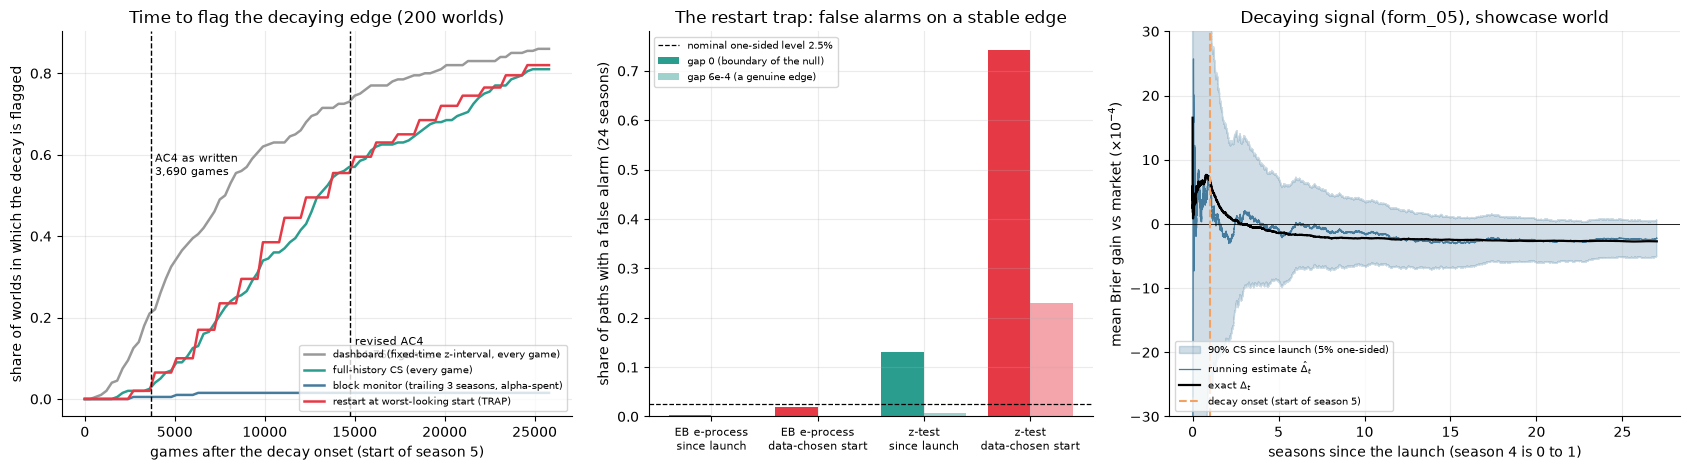

In [13]:
# Visualization only: uses DETECT, MC, showcase decay path computed above.
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw=dict(width_ratios=[1.15, 1, 1.15]))
grid = np.arange(0, 26000, 300)
mcols = [PALETTE["threshold"], PALETTE["valid"], PALETTE["band"], PALETTE["trap"]]
for (name, t_dec), col in zip(DETECT.items(), mcols):
    ok = np.isfinite(t_dec) & (t_dec >= 1)
    ax[0].plot(grid, [(ok & (t_dec <= g)).mean() for g in grid], color=col, lw=1.8, label=name)
ax[0].axvline(3690, color="k", ls="--", lw=1); ax[0].text(3900, 0.55, "AC4 as written\n3,690 games", fontsize=8)
ax[0].axvline(AC4_REV, color="k", ls="--", lw=1); ax[0].text(AC4_REV + 250, 0.10, "revised AC4\n14,760 games", fontsize=8)
ax[0].set_xlabel("games after the decay onset (start of season 5)"); ax[0].set_ylabel("share of worlds in which the decay is flagged")
ax[0].set_title("Time to flag the decaying edge (200 worlds)"); ax[0].legend(fontsize=7.5, loc="lower right")
lab = ["EB e-process\nsince launch", "EB e-process\ndata-chosen start", "z-test\nsince launch", "z-test\ndata-chosen start"]
keys = ["e_fixed", "e_trap", "z_fixed", "z_trap"]
xb = np.arange(4)
ax[1].bar(xb - 0.2, [MC[0.0][k] for k in keys], 0.4, color=[PALETTE["valid"], PALETTE["trap"], PALETTE["valid"], PALETTE["trap"]], label="gap 0 (boundary of the null)")
ax[1].bar(xb + 0.2, [MC[6e-4][k] for k in keys], 0.4, color=[PALETTE["valid"], PALETTE["trap"], PALETTE["valid"], PALETTE["trap"]], alpha=0.45, label="gap 6e-4 (a genuine edge)")
ax[1].axhline(0.025, color="k", ls="--", lw=0.9, label="nominal one-sided level 2.5%")
ax[1].set_xticks(xb); ax[1].set_xticklabels(lab, fontsize=8); ax[1].set_ylabel("share of paths with a false alarm (24 seasons)")
ax[1].set_title("The restart trap: false alarms on a stable edge"); ax[1].legend(fontsize=7.5)
gx = np.arange(1, len(lo_d[0]) + 1) / GPS
ax[2].fill_between(gx, 1e4 * lo_d[0], 1e4 * up_d[0], color=PALETTE["band"], alpha=0.25, label="90% CS since launch (5% one-sided)")
ax[2].plot(gx, 1e4 * Dh_d, color=PALETTE["band"], lw=0.9, label=r"running estimate $\hat\Delta_t$")
ax[2].plot(gx, 1e4 * Dx_d, color="k", lw=1.6, label=r"exact $\Delta_t$")
ax[2].axhline(0, color="k", lw=0.6); ax[2].axvline(1, color=PALETTE["decay"], ls="--", label="decay onset (start of season 5)")
if cross_cs:
    ax[2].axvline(cross_cs / GPS, color=PALETTE["trap"], ls=":", label="CS upper end < 0")
ax[2].set_ylim(-30, 30); ax[2].set_xlabel("seasons since the launch (season 4 is 0 to 1)"); ax[2].set_ylabel(r"mean Brier gain vs market ($\times10^{-4}$)")
ax[2].set_title(f"Decaying signal ({NAMES[DEC]}), showcase world"); ax[2].legend(fontsize=7.5, loc="lower left")
plt.tight_layout(); plt.show()

## 6b. Can any monitor, valid or not, meet AC4 as written?

The revised horizon above keeps the monitor anytime-valid. This section asks the harder question about the criterion **as written in Notebook 2**: is there *any* monitor, including ones with no error guarantee, that flags the decay within 3,690 games in at least half of the worlds with at most 5% false alarms on the genuine edges? The family tried (all *derived here*, fixed in advance, no tuning on the audit): a **fixed-checkpoint block $z$-test** that, at every season end from season 5, takes the trailing 2, 3 or 4 seasons (a predictable subsequence, App. F.1) and alarms when the one-sided $z=-\bar\delta/(s/\sqrt n)$ reaches a threshold of 1.0, 1.28, 1.645 or 2.0. These tests are asymptotically valid *for one pre-specified checkpoint* and have **no anytime error guarantee**: their false-alarm rate at a zero gap over 24 seasons of checkpoints is printed from a Monte Carlo, so that a variant that 'meets' the criterion cannot hide what it costs.

**Result (200 audit worlds, printed below).** No variant of the family meets the criterion as written. The frontier is tight rather than empty: the variant closest to both requirements (a 1.645 threshold on the trailing three seasons) flags 0.535 of the worlds within 3,690 games but raises false alarms on 5.9% of the genuine edges (Wilson interval 4.9% to 7.2%), and at a zero gap it false-alarms in 54.5% of the paths; the variant that stays inside the false-alarm allowance with the most detection (a 1.645 threshold on four seasons has 4.3% false alarms but flags 0.26; a 2.0 threshold on two or three seasons flags 0.385) is far below the required half. Detection of at least 0.5 within 3,690 games therefore costs false alarms above the 5% allowance on the genuine edges, whether or not the monitor is valid, which is the statement that the criterion as written sits at the ceiling of the information in the data.

In [14]:
t0 = time.time()
ZGRID, WGRID = (1.0, 1.28, 1.645, 2.0), (2, 3, 4)      # one-sided z threshold, trailing block length in seasons (checkpoints at every season end from season 5)
SIG = np.r_[dec_i, edge_ids]
def frontier_world(seed):
    W = simulate_world(int(seed), CFG3); Fz = fit_forecasters(W, CFG3)
    q, y, s = W["m_devig"], W["y"].astype(float), W["season"]
    P = cap_forecasts(Fz["P"], q); d = score_diff(P, q[:, None], y[:, None])
    x = d[s >= 4][:, SIG].T
    C1 = np.concatenate([np.zeros((len(SIG), 1)), np.cumsum(x, 1)], 1); C2 = np.concatenate([np.zeros((len(SIG), 1)), np.cumsum(x ** 2, 1)], 1)
    out = np.full((len(ZGRID), len(WGRID), len(SIG)), -1)              # first alarming checkpoint season (5..30) per signal, -1 = never
    for j in range(5, 31):
        t = (j - 3) * GPS
        for b, win in enumerate(WGRID):
            a = max(0, (j - win - 3) * GPS); n = t - a
            m = (C1[:, t] - C1[:, a]) / n; v = np.maximum((C2[:, t] - C2[:, a]) / n - m ** 2, 1e-12)
            z = -m / np.sqrt(v / n)
            for k, zc in enumerate(ZGRID):
                hit = (z >= zc) & (out[k, b] < 0); out[k, b][hit] = j
    return out
seeds_f = [int(x) for x in WORLD_SEEDS]
workers_f = int(os.environ.get("NB3_WORKERS", max(1, min(8, (os.cpu_count() or 2) - 1))))
if "fork" in mp.get_all_start_methods() and workers_f > 1:
    with mp.get_context("fork").Pool(workers_f) as pool:
        FR = np.array(pool.map(frontier_world, seeds_f, chunksize=2))
else:
    FR = np.array([frontier_world(sd) for sd in seeds_f])
def mc_gap0_all(n_paths=1000, seasons=24, sd=0.03, seed=SEED_MC):
    """False-alarm share at a zero gap (boundary of the null) for every (z threshold, block) variant, on shared toy paths."""
    rng = np.random.default_rng(seed); T = GPS * seasons; hit = {(zc, win): 0 for zc in ZGRID for win in WGRID}
    for ch in range(n_paths // 250):
        x = np.clip(sd * rng.standard_normal((250, T)), -0.16, 0.16)
        C1 = np.concatenate([np.zeros((250, 1)), np.cumsum(x, 1)], 1); C2 = np.concatenate([np.zeros((250, 1)), np.cumsum(x ** 2, 1)], 1)
        f = {kk: np.zeros(250, dtype=bool) for kk in hit}
        for k in range(2, seasons + 1):
            t = k * GPS
            for win in WGRID:
                a = max(0, (k - win) * GPS); n = t - a
                m = (C1[:, t] - C1[:, a]) / n; v = np.maximum((C2[:, t] - C2[:, a]) / n - m ** 2, 1e-12)
                z = -m / np.sqrt(v / n)
                for zc in ZGRID:
                    f[(zc, win)] |= z >= zc
        for kk in hit:
            hit[kk] += int(f[kk].sum())
    return {kk: v / (250 * (n_paths // 250)) for kk, v in hit.items()}
G0 = mc_gap0_all()
frows, FRONTIER = [], {}
for k, zc in enumerate(ZGRID):
    for b, win in enumerate(WGRID):
        dec = FR[:, k, b, 0]; edg = FR[:, k, b, 1:]
        det3 = float(((dec >= 5) & ((dec - 4) * GPS <= AC4_ORIG)).mean()); det12 = float(((dec >= 5) & ((dec - 4) * GPS <= AC4_REV)).mean())
        fa_k = int((edg >= 0).sum()); fa_n = edg.size; fa_w = wilson(fa_k, fa_n); g0 = G0[(zc, win)]
        FRONTIER[(zc, win)] = dict(det3=det3, det12=det12, fa=fa_k / fa_n, fa_up=fa_w[1], g0=g0, ok=(det3 >= 0.5) and (fa_w[1] <= 0.05))
        frows.append({"z threshold": zc, "block (seasons)": win, "flagged within 3,690 games": round(det3, 3), "flagged within 14,760 games": round(det12, 3),
                      "false alarms on genuine edges [Wilson]": f"{fa_k / fa_n:.4f} [{fa_w[0]:.4f}, {fa_w[1]:.4f}]", "false alarms at gap 0 (MC, 24 seasons)": round(g0, 3),
                      "AC4 as written": "MET" if FRONTIER[(zc, win)]["ok"] else "NOT MET"})
print("Fixed-checkpoint block z-test monitors (no anytime guarantee), 200 worlds, decay flagged by the end of season 7 = within 3,690 games of the onset:")
print(pd.DataFrame(frows).to_string(index=False))
FRONTIER_OK = [kk for kk, v in FRONTIER.items() if v["ok"]]
best_fa = max((v for v in FRONTIER.values() if v["fa_up"] <= 0.05), key=lambda v: v["det3"], default=None)
print("\nvariants meeting AC4 as written (>= 0.5 flagged within 3,690 games and Wilson upper end of the false-alarm rate <= 5%): " + (", ".join(f"z>={a}, {w} seasons" for a, w in FRONTIER_OK) if FRONTIER_OK else "none"))
if best_fa is not None:
    print(f"the highest detection reachable while keeping the false-alarm upper end at or below 5%: {best_fa['det3']:.3f} flagged within 3,690 games")
print(f"(cell time {time.time() - t0:.1f}s)")

Fixed-checkpoint block z-test monitors (no anytime guarantee), 200 worlds, decay flagged by the end of season 7 = within 3,690 games of the onset:
 z threshold  block (seasons)  flagged within 3,690 games  flagged within 14,760 games false alarms on genuine edges [Wilson]  false alarms at gap 0 (MC, 24 seasons) AC4 as written
       1.000                2                       0.815                        1.000                0.3044 [0.2823, 0.3274]                                   0.941        NOT MET
       1.000                3                       0.770                        1.000                0.1994 [0.1805, 0.2197]                                   0.903        NOT MET
       1.000                4                       0.500                        1.000                0.1450 [0.1286, 0.1631]                                   0.864        NOT MET
       1.280                2                       0.700                        1.000                0.2019 [0.1829, 0.2222]    

## 7. Money view and the picks feed (derived here: none of the three papers covers profit)

**Brier win versus money.** The sources evaluate forecasts with proper scoring rules and state nothing about profit; here the connection is worked out inside the simulator. A unit stake on a side with true win probability $r$ at decimal odds $o$ has expected profit $ro-1$, so a bet needs $r>1/o$: the **break-even probability** is the reciprocal of the quoted odds (0.5238 at the American price $-110$, decimal 1.909). With the simulator's proportional overround of 4.5% the quoted break-even is $1.045\,m$ for a de-margined price $m$, about two points above the fair price at $m=0.5$. Two betting rules from Notebook 2 are scored exactly, using the true win probabilities: **follow** (back the side the model favours over the market in every game) and **edge** (bet only where the model probability beats $1/o$). Following a forecast that has *no* edge loses about $0.045/1.045\approx4.3\%$ per bet: the vig is a tax on every game, and only an edge larger than the tax pays. Stakes are flat; there is no Kelly sizing, no limits and no slippage.

**The significant-but-unprofitable case.** The sub-vig signal has a positive expected Brier gain over the market (a real edge, and a confidence sequence can prove it given enough games) but a negative expected return if followed every game; under the threshold rule it bets only in the tail where its edge clears the overround. A Brier certificate therefore says the forecast is better than the market, not that a bettor gains.

**Picks feed.** A small sample of what the product would send members: the first 15 games of the last live season of the showcase world, built **only from published signals** through the combined forecaster of section 5. The table is simulated; "certifying signals" lists the published signals whose own forecast points the same way as the pick by at least half a percentage point.

In [15]:
t0 = time.time()
rows = []
for c_ in ["real", "proxy_real", "subvig", "decay", "null", "leaky"]:
    m = CLS == c_
    gm = boot_ci(A["gap_eval"][:, m].mean(axis=1))
    edge_roi = A["roi_edge"][:, m]
    rows.append({"class": c_, "exact Brier gain x1e4 [95% boot]": f"{1e4 * gm[0]:+.2f} [{1e4 * gm[1]:+.2f}, {1e4 * gm[2]:+.2f}]",
                 "ROI, follow rule (%)": round(100 * np.nanmean(A["roi_follow"][:, m]), 2),
                 "ROI, threshold rule (%)": round(100 * np.nanmean(edge_roi), 2) if np.isfinite(edge_roi).any() else None,
                 "bets per 7,380 games (threshold)": int(np.nanmean(A["nb_edge"][:, m])),
                 "share of signal-worlds with threshold ROI > 0": round(float(np.nanmean(np.where(np.isfinite(edge_roi), edge_roi > 0, np.nan))), 3)})
print("Exact expected flat-stake ROI at the margined odds and exact Brier gain over the market, fresh live seasons 25-30, mean over 200 worlds:")
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nvig arithmetic: break-even probability at -110 (decimal {1 + 100 / 110:.4f}) = {1 / (1 + 100 / 110):.4f}; "
      f"loss per bet of a zero-edge follower at a 4.5% overround = {100 * 0.045 / 1.045:.2f}%")
print(f"combined forecaster (Hedge pool), threshold rule, exact expected ROI {100 * np.nanmean(A['comb_hybrid_roi_edge']):+.2f}% on {int(A['comb_hybrid_nbets'].mean())} bets per 7,380 games; "
      f"naive stack {100 * np.nanmean(A['comb_naive_stack_roi_edge']):+.2f}% on {int(A['comb_naive_stack_nbets'].mean())} bets")

# the published signals of the showcase world, one by one (exact, fresh window, this world)
evw = (sS >= EVAL_FIRST) & (sS <= EVAL_LAST)
ef_ = expected_roi_flat(PS[:, pub_ids], ohS, oaS, rS, mask=evw, rule="follow", q=qS)
ee_ = expected_roi_flat(PS[:, pub_ids], ohS, oaS, rS, mask=evw, rule="edge")
print(f"\nPublished signals of the showcase world (seed {SHOW_SEED}), exact on the fresh window:")
print(pd.DataFrame({"signal": [NAMES[i] for i in pub_ids], "class": [CLS[i] for i in pub_ids], "exact Brier gain x1e4": np.round(1e4 * exS[evw][:, pub_ids].mean(0), 2),
                    "ROI follow (%)": np.round(100 * ef_["roi"], 2), "ROI threshold (%)": np.round(100 * ee_["roi"], 2), "bets (threshold)": ee_["n_bets"].astype(int)}).to_string(index=False))

# checks
sv = CLS == "subvig"
g_sv = boot_ci(A["gap_eval"][:, sv][:, 0]); f_sv = boot_ci(A["roi_follow"][:, sv][:, 0])
check("hand calculation: break-even probability at -110 is 1/(1 + 100/110)", f"{1 / (1 + 100 / 110):.4f}", "0.5238 (+-1e-4)", abs(1 / (1 + 100 / 110) - 0.5238) < 1e-4)
check("sub-vig signal, fresh window, capped forecaster: exact Brier gain is positive (x1e4) [95% bootstrap]", f"{1e4 * g_sv[0]:+.2f} [{1e4 * g_sv[1]:+.2f}, {1e4 * g_sv[2]:+.2f}]", "lower end > 0", g_sv[1] > 0)
check("sub-vig signal followed in every game: exact expected ROI at the margined odds (%) [95% bootstrap]", f"{100 * f_sv[0]:+.2f} [{100 * f_sv[1]:+.2f}, {100 * f_sv[2]:+.2f}]", "upper end < 0", f_sv[2] < 0)
# realised versus exact ROI of the combined forecaster in the showcase world (money layer coherence, exported roi_flat / expected_roi_flat)
mh = sS >= 4
evh = (sS[mh] >= EVAL_FIRST) & (sS[mh] <= EVAL_LAST)
fcS = qS[mh] + np.clip(hybS - qS[mh], -KAPPA, KAPPA)
rr = roi_flat(fcS, ohS[mh], oaS[mh], WS["y"][mh], mask=evh)
ee = expected_roi_flat(fcS, ohS[mh], oaS[mh], rS[mh], mask=evh)
se_r = 1.3 / np.sqrt(max(rr["n_bets"], 1))
check("showcase world: realised ROI of the combined forecaster equals its exact expected ROI within 4 standard errors (|diff| / se; se = 1.3/sqrt(bets))",
      f"realised {100 * rr['roi']:+.1f}%, exact {100 * ee['roi']:+.1f}%, {int(rr['n_bets'])} bets, z = {abs(rr['roi'] - ee['roi']) / se_r:.2f}", "< 4", abs(rr["roi"] - ee["roi"]) / se_r < 4)

# picks feed: first 15 games of the last live season, combined forecaster built from published signals only
PC = np.full(len(qS), np.nan); PC[mh] = fcS
g_idx = np.where(sS == EVAL_LAST)[0][:15]
pub_names = [NAMES[i] for i in pub_ids]
picks = []
for g in g_idx:
    p, q_, oh_, oa_ = PC[g], qS[g], ohS[g], oaS[g]
    if p * oh_ > 1:
        side, mp, mk, od = "home", p, q_, oh_
    elif (1 - p) * oa_ > 1:
        side, mp, mk, od = "away", 1 - p, 1 - q_, oa_
    else:
        side = None
    if side is None:
        picks.append({"game": int(g - np.where(sS == EVAL_LAST)[0][0] + 1), "side": "no bet", "model prob": None, "market prob": None, "edge (pp)": None,
                      "quoted odds": None, "EV per unit (%)": None, "certifying signals": "-", "status": "not a pick"})
        continue
    sgn = 1.0 if side == "home" else -1.0
    cert = [NAMES[i] for i in pub_ids if sgn * (PS[g, i] - q_) >= 0.005]
    picks.append({"game": int(g - np.where(sS == EVAL_LAST)[0][0] + 1), "side": side, "model prob": round(mp, 3), "market prob": round(mk, 3),
                  "edge (pp)": round(100 * (mp - mk), 1), "quoted odds": od, "EV per unit (%)": round(100 * (mp * od - 1), 1),
                  "certifying signals": ", ".join(cert) if cert else "(combination only)", "status": "published (registry, stage 2)"})
picks_tab = pd.DataFrame(picks)
print(f"\nPICKS FEED (SIMULATED; showcase world seed {SHOW_SEED}, season {EVAL_LAST}, first 15 games; published signals in this world: {', '.join(pub_names)}):")
print(picks_tab.fillna('-').to_string(index=False))
print(f"(cell time {time.time() - t0:.1f}s)")

Exact expected flat-stake ROI at the margined odds and exact Brier gain over the market, fresh live seasons 25-30, mean over 200 worlds:
     class exact Brier gain x1e4 [95% boot]  ROI, follow rule (%)  ROI, threshold rule (%)  bets per 7,380 games (threshold)  share of signal-worlds with threshold ROI > 0
      real             +6.18 [+6.10, +6.25]                 -0.42                     3.10                              2714                                          0.986
proxy_real             +4.71 [+4.61, +4.81]                 -0.85                     2.91                              2295                                          1.000
    subvig             +2.14 [+2.00, +2.28]                 -1.96                     1.49                              1623                                          0.784
     decay             -8.00 [-8.57, -7.44]                 -4.58                    -4.94                              3005                                          0.000
   

**How to read this chart** *(two panels; one dot per signal and world; fresh seasons 25-30)*

The x-axis is the exact mean Brier gain over the de-margined market in units of $10^{-4}$ (positive: better than the market); the y-axis is the exact expected flat-stake ROI at the margined odds, in percent. The left panel follows the signal in *every* game, the right panel bets only where the model probability beats $1/\text{odds}$. Big markers are class means. Left: the relation between Brier gain and money is roughly a line that crosses zero only at a gain of about $7\times10^{-4}$ per game: signals with smaller gains lose money if followed in every game, and the sub-vig class (yellow) has a positive Brier gain and a negative return, the leaky class (red) and the decaying class (orange) lose the vig and more, and no-effect signals lose about the 4% tax. Right: the threshold rule turns the same forecasts into a positive expected return for the genuine edges by placing bets only where the edge exceeds the tax, at the cost of far fewer bets; for the no-effect classes it places only a few hundred bets, so their ROI is very noisy (the vertical smear), and on average it loses more per bet than following, because a bet chosen on noise has no edge to pay the tax. For the project: a certificate about Brier is a certificate about forecast quality; whether members can profit depends on the tail of the edge, the stake rule and the price, none of which the papers address.

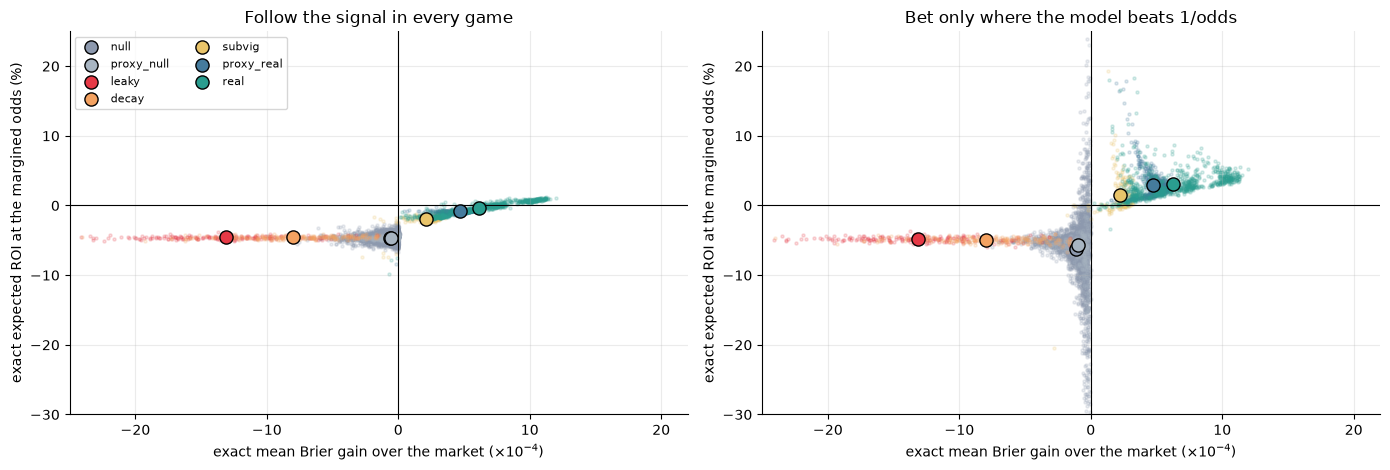

In [16]:
# Visualization only: uses A, CLS computed above.
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for k, (key, title) in enumerate((("roi_follow", "Follow the signal in every game"), ("roi_edge", "Bet only where the model beats 1/odds"))):
    for c_ in ["null", "proxy_null", "leaky", "decay", "subvig", "proxy_real", "real"]:
        m = CLS == c_
        x, y = 1e4 * A["gap_eval"][:, m].ravel(), 100 * A[key][:, m].ravel()
        ok = np.isfinite(y)
        ax[k].scatter(x[ok], y[ok], s=5, color=PALETTE[c_], alpha=0.18)
        ax[k].scatter([x[ok].mean()], [y[ok].mean()], s=90, color=PALETTE[c_], edgecolor="k", label=c_, zorder=5)
    ax[k].axhline(0, color="k", lw=0.8); ax[k].axvline(0, color="k", lw=0.8)
    ax[k].set_xlabel(r"exact mean Brier gain over the market ($\times10^{-4}$)"); ax[k].set_ylabel("exact expected ROI at the margined odds (%)")
    ax[k].set_title(title); ax[k].set_xlim(-25, 22); ax[k].set_ylim(-30, 25)
ax[0].legend(fontsize=8, ncol=2, loc="upper left")
plt.tight_layout(); plt.show()

## 8. The scorecard: four acceptance criteria against the naive baseline

Every number below is computed by code from the audits; nothing is typed. The **baseline** column for AC1 and AC2 is the Notebook 2 audit read from its cache (`nb02_audit_200worlds.npz`: the naive screen on 200 worlds with 3 live seasons; if the cache is absent the baseline is recomputed from the naive screen on this notebook's own worlds, which the checks above show agrees with it). For AC3 and AC4 Notebook 2 audited no baseline, so the baseline is the client's own practice run on this notebook's worlds: the naive stack (its published set and weights from the backtest window, capped like every forecaster) for AC3, and the fixed-time dashboard refreshed after every game for AC4. The **pipeline** column is the two-stage registry (AC1, AC2), the combined forecaster of section 5 (AC3) and the best valid monitor, the full-history confidence sequence (AC4).

Verdict rules, all following the criteria as written in Notebook 2:

* **AC1** met iff the upper end of the 95% bootstrap interval for the mean FDP is at most 0.10 (the rule Notebook 2 used for its baseline verdict);
* **AC2** met iff the observed share of worlds in which the leaky signal is published is at most 0.01. The Wilson upper end is printed beside it: with 200 worlds an observed zero cannot rule out a true rate of about 2%, so a "met" here is a statement about the observed share and not a proof of the 1% bound;
* **AC3** met iff the mean over worlds of the lower end of the 95% confidence sequence (fresh seasons 25-30) is at least $-0.0005$; the share of worlds with lower end at least $-0.0005$ is printed beside it;
* **AC4 (revised horizon, the scorecard's fourth row)** met iff the decay is flagged within 14,760 games of the onset in at least half of the worlds **and** false alarms on the stable edges are at most 5% (per world and edge), judged on the observed shares; the Wilson interval of the detection share is printed in section 6;
* **AC4 as written in Notebook 2 (a fifth row)**: the same rule with 3,690 games. It is reported so that the revision cannot hide it, and section 6b shows that no monitor of the fixed-checkpoint family, valid or not, meets it (a row would be added below only if one did).


In [17]:
t0 = time.time()
# ---- baseline for AC1 / AC2 from the Notebook 2 audit cache ----
NB2_CACHE = DATA_DIR / "nb02_audit_200worlds.npz"
if NB2_CACHE.exists():
    z2 = np.load(NB2_CACHE, allow_pickle=False)
    sel2, gap2 = z2["selected"].astype(bool), z2["gap"]
    fdp_base = fdp_of(sel2, gap2 > 0); leak_base = int(sel2[:, IS_LEAKY].sum()); n_base = sel2.shape[0]; base_src = "Notebook 2 audit cache"
else:
    fdp_base = REG["naive (Notebook 2)"]["fdp"]; leak_base = REG["naive (Notebook 2)"]["leaky"]; n_base = N_WORLDS; base_src = "recomputed on this notebook's worlds"
fb = boot_ci(fdp_base); fp_ = boot_ci(REG["two-stage, flat gamma (registry)"]["fdp"])
lk_pipe = REG["two-stage, flat gamma (registry)"]["leaky"]; wb, wp = wilson(leak_base, n_base), wilson(lk_pipe, N_WORLDS)
# AC3
lo_base, lo_pipe = A["comb_naive_stack_lower"], A["comb_hybrid_lower"]
# AC4
def ac4(name, horizon=AC4_REV):
    t = DETECT[name]; in_time = float((np.isfinite(t) & (t >= 1) & (t <= horizon)).mean())
    fa = false_alarm_flags(MON[name]); return in_time, float(fa.mean()), wilson(int(fa.sum()), fa.size)
dash_in, dash_fa, dash_w = ac4("dashboard (fixed-time z-interval, every game)")
cs_in, cs_fa, cs_w = ac4("full-history CS (every game)")
blk_in, blk_fa, blk_w = ac4("block monitor (trailing 3 seasons, alpha-spent)")
dash_in0 = ac4("dashboard (fixed-time z-interval, every game)", AC4_ORIG)[0]; cs_in0 = ac4("full-history CS (every game)", AC4_ORIG)[0]
tr_in, tr_fa, tr_w = ac4("restart at worst-looking start (TRAP)")
V = lambda ok: "MET" if ok else "NOT MET"
sc = {
    "AC1": dict(base=fb[0], base_txt=f"mean FDP {fb[0]:.3f} [{fb[1]:.3f}, {fb[2]:.3f}]", base_ok=fb[2] <= 0.10,
                pipe=fp_[0], pipe_txt=f"mean FDP {fp_[0]:.3f} [{fp_[1]:.3f}, {fp_[2]:.3f}]", pipe_ok=fp_[2] <= 0.10),
    "AC2": dict(base=leak_base / n_base, base_txt=f"leaky published in {leak_base / n_base:.3f} of worlds (Wilson upper {wb[1]:.3f})", base_ok=leak_base / n_base <= 0.01,
                pipe=lk_pipe / N_WORLDS, pipe_txt=f"leaky published in {lk_pipe / N_WORLDS:.3f} of worlds (Wilson upper {wp[1]:.3f})", pipe_ok=lk_pipe / N_WORLDS <= 0.01),
    "AC3": dict(base=lo_base.mean(), base_txt=f"mean lower end {1e4 * lo_base.mean():+.2f}e-4 ({(lo_base >= -5e-4).mean():.0%} of worlds >= -5e-4)", base_ok=lo_base.mean() >= -5e-4,
                pipe=lo_pipe.mean(), pipe_txt=f"mean lower end {1e4 * lo_pipe.mean():+.2f}e-4 ({(lo_pipe >= -5e-4).mean():.0%} of worlds >= -5e-4)", pipe_ok=lo_pipe.mean() >= -5e-4),
    "AC4": dict(base=dash_in, base_txt=f"flagged in time {dash_in:.3f}; false alarms {dash_fa:.3f}", base_ok=(dash_in >= 0.5) and (dash_fa <= 0.05),
                pipe=cs_in, pipe_txt=f"flagged in time {cs_in:.3f}; false alarms {cs_fa:.4f}", pipe_ok=(cs_in >= 0.5) and (cs_w[1] <= 0.05)),
}
crit = {"AC1": "mean FDP among published signals <= 0.10", "AC2": "look-ahead signal published in <= 1% of worlds",
        "AC3": "CS lower end of combined forecast vs market >= -0.0005", "AC4": "decay flagged within 14,760 games (revised) in >= 50% of worlds, false alarms <= 5%"}
tab = pd.DataFrame([{"AC": k, "criterion": crit[k], "baseline (naive / client practice)": v["base_txt"], "baseline verdict": V(v["base_ok"]),
                     "this pipeline": v["pipe_txt"], "pipeline verdict": V(v["pipe_ok"])} for k, v in sc.items()])
_o_b = (dash_in0 >= 0.5) and (dash_fa <= 0.05); _o_p = (cs_in0 >= 0.5) and (cs_w[1] <= 0.05)
tab.loc[len(tab)] = {"AC": "AC4 (as written in Notebook 2)", "criterion": "decay flagged within 3,690 games in >= 50% of worlds, false alarms <= 5%", "baseline (naive / client practice)": f"flagged in time {dash_in0:.3f}; false alarms {dash_fa:.3f}", "baseline verdict": V(_o_b), "this pipeline": f"flagged in time {cs_in0:.3f}; false alarms {cs_fa:.4f}", "pipeline verdict": V(_o_p)}
for (_zc, _w), _v in FRONTIER.items():
    if _v["ok"]:
        tab.loc[len(tab)] = {"AC": f"AC4 as written, non-valid variant (z>={_zc}, {_w} seasons)", "criterion": "decay flagged within 3,690 games in >= 50% of worlds, false alarms <= 5%", "baseline (naive / client practice)": f"flagged in time {dash_in0:.3f}; false alarms {dash_fa:.3f}", "baseline verdict": V(_o_b), "this pipeline": f"flagged in time {_v['det3']:.3f}; false alarms {_v['fa']:.4f} (but {_v['g0']:.3f} at a zero gap: no anytime guarantee)", "pipeline verdict": "MET"}
pd.set_option("display.width", 250); pd.set_option("display.max_colwidth", 90)
print(f"SCORECARD (baseline AC1/AC2 source: {base_src}; all numbers computed from the audits above)")
print(tab.to_string(index=False))
print("\nwhat decides each row:")
print(f"  AC1: pipeline upper bootstrap end {fp_[2]:.3f} vs target 0.100 (baseline {fb[2]:.3f}); power paid for it: {REG['two-stage, flat gamma (registry)']['pub_per_world']:.2f} signals published per world, "
      f"real edges published {REG['two-stage, flat gamma (registry)']['power']['real']:.2f}, proxy-real {REG['two-stage, flat gamma (registry)']['power']['proxy_real']:.2f}")
print(f"  AC2: observed share {lk_pipe / N_WORLDS:.3f} vs target 0.010; Wilson upper {wp[1]:.3f} (200 worlds cannot show the 1% bound tightly); baseline {leak_base / n_base:.3f}")
print(f"  AC3: mean lower end {1e4 * lo_pipe.mean():+.2f}e-4 vs bar -5e-4; naive stack {1e4 * lo_base.mean():+.2f}e-4 (the stack has the larger gain, {1e4 * A['comb_naive_stack_gap'].mean():+.2f}e-4 vs {1e4 * A['comb_hybrid_gap'].mean():+.2f}e-4 exact)")
print(f"  AC4 (revised, {AC4_REV:,} games): flagged in time by the full-history CS {cs_in:.3f} (block monitor {blk_in:.3f}, trap {tr_in:.3f}, dashboard {dash_in:.3f}); false alarms CS {cs_fa:.4f}, block {blk_fa:.4f}, "
      f"trap {tr_fa:.4f}, dashboard {dash_fa:.3f}; median games to flag with the CS: {np.nanmedian(DETECT['full-history CS (every game)']):.0f} after the onset "
      f"(flagged eventually in {np.isfinite(DETECT['full-history CS (every game)']).mean():.2f} of worlds)")
t_cs = DETECT["full-history CS (every game)"]
print("  AC4 frontier (section 6b): " + (f"{len(FRONTIER_OK)} non-valid variants meet the criterion as written" if FRONTIER_OK else "no monitor of the family, valid or not, meets the criterion as written"))
print(f"  AC4 as written (3,690 games): full-history CS {cs_in0:.3f}, dashboard {dash_in0:.3f} of worlds flagged in time")
print("  games-to-detect distribution after the onset, full-history CS (quantiles over worlds that flag): "
      + ", ".join(f"{int(q * 100)}%: {np.nanquantile(t_cs[np.isfinite(t_cs)], q):,.0f}" for q in (0.1, 0.25, 0.5, 0.75, 0.9)))
check("scorecard consistency: the AC1 baseline computed here from the audit equals the Notebook 2 headline (0.187) to the printed precision", f"{fb[0]:.3f}",
      "0.187 +- 0.005 (source: Notebook 2 audit cache)" if NB2_CACHE.exists() else "0.15-0.23 (recomputed)", (abs(fb[0] - 0.187) < 0.005) if NB2_CACHE.exists() else (0.15 <= fb[0] <= 0.23))
print(f"(cell time {time.time() - t0:.1f}s)")

SCORECARD (baseline AC1/AC2 source: recomputed on this notebook's worlds; all numbers computed from the audits above)
                            AC                                                                           criterion                      baseline (naive / client practice) baseline verdict                                           this pipeline pipeline verdict
                           AC1                                            mean FDP among published signals <= 0.10                           mean FDP 0.189 [0.178, 0.200]          NOT MET                           mean FDP 0.000 [0.000, 0.000]              MET
                           AC2                                      look-ahead signal published in <= 1% of worlds leaky published in 0.955 of worlds (Wilson upper 0.976)          NOT MET leaky published in 0.000 of worlds (Wilson upper 0.019)              MET
                           AC3                              CS lower end of combined forecast vs ma

**How to read this chart** *(four panels, one per acceptance criterion; red: the client's baseline, green: this pipeline, dashed line: the criterion)*

AC1 (mean false-discovery proportion) and AC2 (share of worlds in which the look-ahead signal is published) are *lower is better*; AC3 (mean lower end of the 95% interval for the combined forecast's gain over the market, in units of $10^{-4}$) and AC4 (share of worlds in which the decay is flagged within the revised 14,760 games) are *higher is better*. A bar on the good side of its dashed line is a criterion met. The pipeline meets all four panels; the baseline fails AC1 and AC2, meets AC3 (its stack has the larger gain but no certificate), and fails AC4 because its dashboard raises false alarms on 12% of the stable edges. The fourth panel uses the revised horizon; the criterion as written (3,690 games) is **not met by either side** (0.025 for the pipeline) and is printed in the scorecard table above. The bars carry the numbers of the printed scorecard, so the picture and the table cannot disagree.

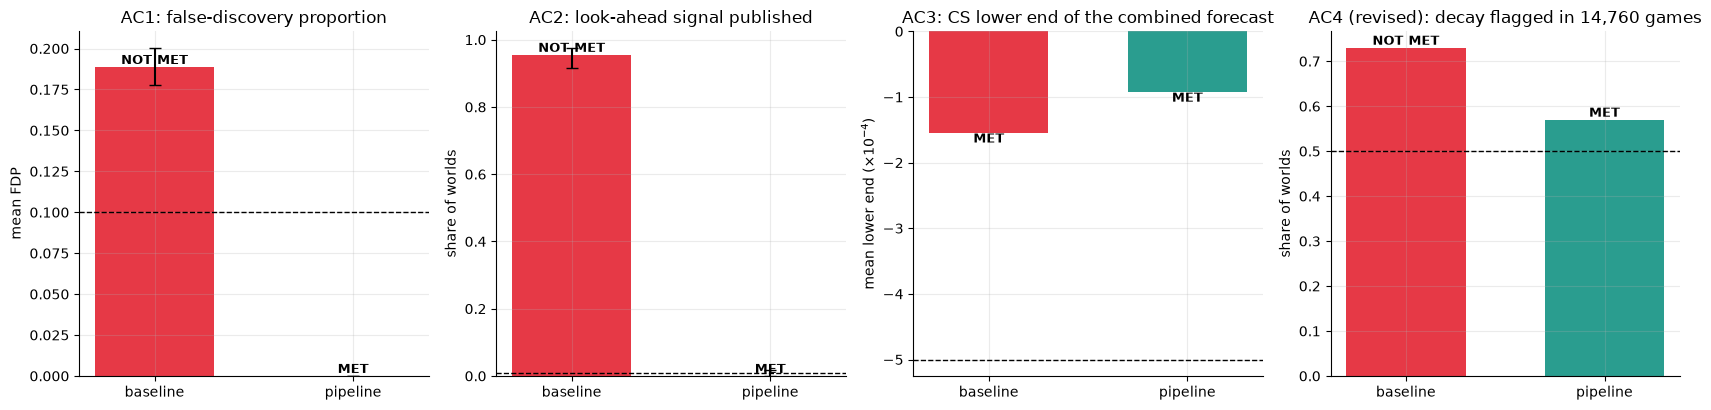

In [18]:
# Visualization only: uses sc, fb, fp_, wb, wp computed above.
fig, ax = plt.subplots(1, 4, figsize=(17, 4.2))
def panel(a, key, title, target, ylabel, scale=1.0, yerr=None):
    vals = [sc[key]["base"] * scale, sc[key]["pipe"] * scale]
    a.bar([0, 1], vals, color=[PALETTE["naive"], PALETTE["two_stage"]], yerr=yerr, capsize=4, width=0.6)
    a.axhline(target * scale, color="k", ls="--", lw=1); a.set_xticks([0, 1]); a.set_xticklabels(["baseline", "pipeline"]); a.set_title(title); a.set_ylabel(ylabel)
    for i, k in enumerate(("base_ok", "pipe_ok")):
        a.text(i, vals[i], "MET" if sc[key][k] else "NOT MET", ha="center", va="bottom" if vals[i] >= 0 else "top", fontsize=9, fontweight="bold")
panel(ax[0], "AC1", "AC1: false-discovery proportion", 0.10, "mean FDP", yerr=[[fb[0] - fb[1], fp_[0] - fp_[1]], [fb[2] - fb[0], fp_[2] - fp_[0]]])
panel(ax[1], "AC2", "AC2: look-ahead signal published", 0.01, "share of worlds", yerr=[[sc["AC2"]["base"] - wb[0], sc["AC2"]["pipe"] - wp[0]], [wb[1] - sc["AC2"]["base"], wp[1] - sc["AC2"]["pipe"]]])
panel(ax[2], "AC3", "AC3: CS lower end of the combined forecast", -5e-4, r"mean lower end ($\times10^{-4}$)", scale=1e4)
panel(ax[3], "AC4", "AC4 (revised): decay flagged in 14,760 games", 0.5, "share of worlds")
plt.tight_layout(); plt.show()

## 9. Limitations and what these results do not say

* **The simulator is the world.** Every number is a property of the planted structure: 40 signals with a fixed class layout, effect sizes of 2 to 3.5 points per standard deviation, a proportional 4.5% overround, one planted mispricing, one clean additive leak. The cost of proof (a median of about 8,000 to 13,000 live games for the real edges that are certified at all within 22,000 games, and 8% to 55% of the real edges are not certified by then) is a consequence of those effect sizes; a market with larger inefficiencies would be provable sooner, a real one with smaller ones never. The constants (`KAPPA`, `V_OPT`, the shortlist threshold, the grid) were chosen on prototype worlds, not on the audit, but they are still design choices of this study. **Two choices were made after an audit had been seen**, and are disclosed in section 6: the monitor's level (`ALPHA_MON`) was raised after a first audit showed 0.480 detection within the revised horizon, and the revised AC4 horizon itself replaces one that is unreachable; the monitor change was first checked on 60 disjoint prototype worlds and the audit was re-run once.
* **Money is outside the sources.** The three papers evaluate forecasts with proper scoring rules. They do not model profit, margin and de-margining beyond one rescaling, Kelly staking or any stake rule, transaction costs, commissions, bet limits, the favourite-longshot bias or three-way outcomes, and none states that a better Brier score than the bookmaker implies a positive return. The ROI figures (flat stakes, two betting rules, a proportional overround, no limits or slippage, exact expectations from the simulator's true probabilities) are *derived here*. A Brier win is not profit: the sub-vig case shows a proven edge that loses money when followed. Sportsbook odds are set to maximise the book's profit, not only accuracy (Choe and Ramdas, Sec. 6).
* **Descriptive, not predictive.** A confidence sequence or e-process summarises the gap achieved so far (Choe and Ramdas). A signal certified on 12 live seasons can still decay, which is why deliverable D4 exists; nothing certified here is a forecast of future profit.
* **e-LOND pays a power price and needs a fixed order.** Robustness to arbitrary dependence costs power against methods built for a known dependence (Xu and Ramdas, Sec. 5 and 7); the FDR bound is sharp (App. C), so the levels cannot be raised without further assumptions; the traces do not cover a data-dependent order of hypotheses, so the order is the registration order; and LORD-style memory and SAFFRON/ADDIS-style adaptivity with e-values are open problems. The two-stage registry (sample splitting between a backtest shortlist and a live confirmation, a flat discount sequence over the shortlist, a plain e-value threshold in stage 1) is *derived here*: its FDR statement rests on the validity of stage-2 e-values conditional on the past, and no paper covers this exact construction. Its cost is time: the live confirmation needs many seasons.
* **Predictability is an assumption, not a test.** The certificates are void for a signal whose forecasts use post-game information (section 3 shows this on the backtest); the registry avoids the problem by demanding causal evidence, it does not detect leaks. A leak that also exists in live data would pass.
* **The cap and the tuning of the e-process are derived here.** Capping every forecast at $\pm0.08$ around the market makes the boundedness condition of Thm 2 hold with $c=0.32$ instead of the worst-case $c=2$ and lets the e-process certify anything within the horizon; it also removes the part of a signal's edge that lies in games where it disagrees with the market by more than eight points (a tiny share of games here). The intrinsic-time parameter $v_{\rm opt}$ is a free parameter of the boundary (Choe and Ramdas, App. B.1 and I.4 use 10 and 100 on much larger differentials); here it is 10, chosen on the prototype grid.
* **Calibeating has no experiments in its paper and needs few distinct forecast values.** The guarantees are cumulative, worst-case over an oblivious adversary, and against the refinement score of the *rounded* forecast: they do not say a calibeated forecast beats the raw market, and here it does not (rounding to 20 values and the learning cost outweigh the small planted mispricing). Non-vacuous bounds need $|Q|=o(T/\log T)$. The Hedge pool that keeps raw experts next to calibeated ones goes beyond Algorithm 2 and carries only the Hedge regret guarantee, not the multi-calibeating one.
* **The monitors.** The valid monitors are conservative and slow at this effect size, and the fixed-checkpoint z-tests of section 6b, which are faster, have no anytime error guarantee (false alarms of 27% to 94% at a zero gap depending on the variant); the restart trap is shown with a Monte Carlo on toy paths, not a proof, and a less conservative statistic than the empirical-Bernstein mixture would show a larger inflation. Choe and Ramdas leave lagged forecasts ($h>1$) open and require bounded scores (a log score would need truncation or a Winkler normalisation).
* **Simulator conveniences.** Features are decorrelated within families, the leak is a clean additive contamination, teams do not respond to the market, the truth is a stationary logistic model apart from the one decaying signal, and there are only two outcomes. Real signal libraries are collinear, leaks are subtler, edges are priced away, and a sport with draws needs a different score and money rule.

## 10. Recap

**What was delivered.** A written-up second half of the engagement, run on 200 simulated worlds of 30 seasons each. **Prove**: anytime-valid confidence sequences and e-processes for each signal against the de-margined market, checked for coverage of the exact running gap, for e-value validity on no-effect signals and for the exact CS/e-process duality; shown to be void for a look-ahead signal on the backtest and sound on live data. **Screen**: a two-stage e-LOND registry (a backtest shortlist, then confirmation on live seasons in fixed order) that publishes no false discovery and never the look-ahead signal, at the price of power: about 2.4 signals per world, about 35% of the real edges after 12 live seasons. **Combine**: a Hedge pool over the market and the published signals, raw and calibeated; calibeating alone does not recover the planted mispricing at this data size. **Monitor**: the full-history confidence sequence flags the decaying edge in 57% of the worlds within 12 seasons (median about 12,400 games among the worlds that flag), and practically never within the 3 seasons of the criterion as written; the block monitor practically never; the faster rules are invalid, and the restart trap is quantified. **Money**: Brier gain is not profit; the sub-vig edge is proven and unprofitable when followed. **Cost of proof**: the live games and the vig are the two prices of a provable registry.

**Scorecard** (computed above; see section 8 for the numbers): AC1 and AC2 are met by the pipeline and failed by the naive baseline; AC3 is met by the pipeline (the naive stack also meets it, with a larger exact gain but no certificate for its members); AC4 is **not met as written** (3,690 games) by any valid monitor, nor by any of the twelve non-valid fixed-checkpoint block z-tests of section 6b (the closest flags 0.535 of the worlds with 5.9% false alarms, against a 5% allowance), and is **met with the revised 12-season horizon** by the pipeline (0.570 flagged, false alarms 0.06%) and not by the baseline (false alarms 12%); the revision and the order of the choices are disclosed in section 6.

**How to reproduce.** Run the notebooks in order 1, 2, 3 from the `notebooks/` folder (the project README describes the environment): Notebook 3 loads the marked `# EXPORT:` cells of Notebooks 1 and 2, simulates the 200-world audit in parallel worker processes on its first run and caches it in `data/` (regenerated automatically if the constants change; the audit took about 15 s on 12 cores of a cloud CPU (set the environment variable `NB3_WORKERS` to the number of cores; the default is at most 8 workers) and about 15 minutes serially on one core, and the whole notebook about 20 s when the cache is present), and everything else is a cheap recomputation from the cache. All seeds are fixed; no network, no LLM and no paid API is used anywhere.

In [19]:
n_met = sum(CHECKS); n_all = len(CHECKS)
print(f"SELF-CHECKS in this notebook: {n_met} of {n_all} MET; NOT MET: {[i + 1 for i, ok in enumerate(CHECKS) if not ok]}")
print(f"total run time {time.time() - T_START:.0f}s (audit {AUDIT_SECONDS:.0f}s, {'from cache' if from_cache else 'simulated cold'})")

SELF-CHECKS in this notebook: 29 of 29 MET; NOT MET: []
total run time 38s (audit 16s, simulated cold)
